## Desenvolvimento Caso Prático Datarisk


# 1. Importação das Bibliotecas

In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Oversampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Métricas
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Utilidades
from sklearn.base import clone

# 2. Leitura das Bases de Dados

In [ ]:
#url das bases de dados
base_url = "https://github.com/datarisk-io/datarisk-case-ds-junior/tree/master/data"

#importação dos arquivos
base_cadastral = pd.read_csv(base_url + "base_cadastral.csv", sep=";")
base_info = pd.read_csv(base_url + "base_info.csv", sep=";")
base_pagamentos_dev = pd.read_csv(base_url + "base_pagamentos_desenvolvimento.csv", sep=";")
base_pagamentos_test = pd.read_csv(base_url + "base_pagamentos_teste.csv", sep=";")

# Visualiza as primeiras linhas de cada base
display(base_cadastral.head())
display(base_info.head())
display(base_pagamentos_dev.head())
display(base_pagamentos_test.head())


,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


**Objetivo:**  
Importar todas as bases necessárias para desenvolver o caso prático.

**Por quê?**  
Garantir que todas as etapas do fluxo de dados (limpeza, análise, modelagem) possam acessar as tabelas desde o início.

**Resultados:**  
Todas as bases foram carregadas com sucesso, sem erros de leitura, prontas para o pré-processamento.


# 3. Estrutura Básica de Cada Base

In [8]:
for nome, df in {
    "base_cadastral": base_cadastral,
    "base_info": base_info,
    "base_pagamentos_desenvolvimento": base_pagamentos_dev,
    "base_pagamentos_teste": base_pagamentos_test,
}.items():
    print(f"--- {nome} ---")
    print("Shape:", df.shape)
    print("Colunas:", df.columns.tolist())
    print("Tipos:\n", df.dtypes)
    print("="*40)


--- base_cadastral ---
Shape: (1315, 8)
Colunas: ['ID_CLIENTE', 'DATA_CADASTRO', 'DDD', 'FLAG_PF', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']
Tipos:
 ID_CLIENTE              int64
DATA_CADASTRO          object
DDD                    object
FLAG_PF                object
SEGMENTO_INDUSTRIAL    object
DOMINIO_EMAIL          object
PORTE                  object
CEP_2_DIG              object
dtype: object
--- base_info ---
Shape: (24401, 4)
Colunas: ['ID_CLIENTE', 'SAFRA_REF', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']
Tipos:
 ID_CLIENTE              int64
SAFRA_REF              object
RENDA_MES_ANTERIOR    float64
NO_FUNCIONARIOS       float64
dtype: object
--- base_pagamentos_desenvolvimento ---
Shape: (77414, 7)
Colunas: ['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO', 'VALOR_A_PAGAR', 'TAXA']
Tipos:
 ID_CLIENTE                  int64
SAFRA_REF                  object
DATA_EMISSAO_DOCUMENTO     object
DATA_PAGAMENTO             o

**Objetivo:**  
Verificar o tipo de dado de todas as colunas das bases.

**Por quê?**  
Cada coluna deve estar com o tipo adequado (ex: datas como datetime, valores numéricos como int/float, categorias como object) para evitar erros e facilitar o tratamento, análise estatística e aplicação de funções específicas em etapas posteriores.

**Resultados:**  
A checagem permitiu identificar quais colunas já estavam corretas e quais precisavam de ajuste de tipo, direcionando os próximos passos do pré-processamento.


# 4. Ajuste dos Tipos de Dados

In [11]:

# 1. Ajuste de datas para datetime
for df in [base_info, base_pagamentos_dev, base_pagamentos_test]:
    df['SAFRA_REF'] = pd.to_datetime(df['SAFRA_REF'], format='%Y-%m', errors='coerce')

base_cadastral['DATA_CADASTRO'] = pd.to_datetime(base_cadastral['DATA_CADASTRO'], errors='coerce')

for col in ['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO']:
    if col in base_pagamentos_dev.columns:
        base_pagamentos_dev[col] = pd.to_datetime(base_pagamentos_dev[col], errors='coerce')
    if col in base_pagamentos_test.columns:
        base_pagamentos_test[col] = pd.to_datetime(base_pagamentos_test[col], errors='coerce')

# 2. Variáveis numéricas-categóricas tratadas como string (categóricas)
base_cadastral['DDD'] = base_cadastral['DDD'].astype(str).str.zfill(2)
base_cadastral['CEP_2_DIG'] = base_cadastral['CEP_2_DIG'].astype(str).str.zfill(2)
base_cadastral['FLAG_PF'] = base_cadastral['FLAG_PF'].apply(lambda x: 'PF' if pd.notna(x) and str(x).strip() != '' else 'PJ')

# 3. Outras colunas categóricas
cat_cols_cadastral = ['DDD', 'CEP_2_DIG', 'FLAG_PF', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE']

# 4. Visualize os tipos de dados finais de todas as bases
for nome, df in {
    "base_cadastral": base_cadastral,
    "base_info": base_info,
    "base_pagamentos_desenvolvimento": base_pagamentos_dev,
    "base_pagamentos_teste": base_pagamentos_test,
}.items():
    print(f"\n--- {nome} ---")
    print(df.dtypes)
    print("="*40)



--- base_cadastral ---
ID_CLIENTE                      int64
DATA_CADASTRO          datetime64[ns]
DDD                            object
FLAG_PF                        object
SEGMENTO_INDUSTRIAL            object
DOMINIO_EMAIL                  object
PORTE                          object
CEP_2_DIG                      object
dtype: object

--- base_info ---
ID_CLIENTE                     int64
SAFRA_REF             datetime64[ns]
RENDA_MES_ANTERIOR           float64
NO_FUNCIONARIOS              float64
dtype: object

--- base_pagamentos_desenvolvimento ---
ID_CLIENTE                         int64
SAFRA_REF                 datetime64[ns]
DATA_EMISSAO_DOCUMENTO    datetime64[ns]
DATA_PAGAMENTO            datetime64[ns]
DATA_VENCIMENTO           datetime64[ns]
VALOR_A_PAGAR                    float64
TAXA                             float64
dtype: object

--- base_pagamentos_teste ---
ID_CLIENTE                         int64
SAFRA_REF                 datetime64[ns]
DATA_EMISSAO_DOCUMENTO

**Objetivo:**  
Padronizar os tipos das variáveis para garantir que cada coluna seja interpretada corretamente (datas, categorias, numéricas).

**Por quê?**  
Tipos incorretos podem causar erros em cálculos, análise estatística e processamento, além de inviabilizar o uso correto de funções de data ou de agrupamentos.

**Resultados:**  
Colunas de datas foram convertidas para o tipo datetime, também foram definidas algumas variáveis como categóricas apesar do conteúdo da coluna ser númerico, como foi no caso das colunas FLAG_PF(verifica se é PJ ou pessoa física), DDD e CEP, onde apesar de serem informações preenchidas com números, possuem teor categórico. As variáveis numéricas já estavam definidas corretamente


# 5. Análise de Dados Faltantes

In [14]:
for nome, df in {
    "base_cadastral": base_cadastral,
    "base_info": base_info,
    "base_pagamentos_desenvolvimento": base_pagamentos_dev,
    "base_pagamentos_teste": base_pagamentos_test,
}.items():
    print(f"\n--- {nome} ---")
    nulos = df.isnull().sum()
    percent_nulos = 100 * nulos / len(df)
    display(pd.DataFrame({'Nulos': nulos, '% Nulos': percent_nulos}).sort_values('% Nulos', ascending=False))



--- base_cadastral ---


,Nulos,% Nulos
SEGMENTO_INDUSTRIAL,83,6.311787
PORTE,41,3.117871
DOMINIO_EMAIL,30,2.281369
ID_CLIENTE,0,0.000000
DATA_CADASTRO,0,0.000000
DDD,0,0.000000
FLAG_PF,0,0.000000
CEP_2_DIG,0,0.000000



--- base_info ---


,Nulos,% Nulos
NO_FUNCIONARIOS,1252,5.130937
RENDA_MES_ANTERIOR,717,2.938404
ID_CLIENTE,0,0.000000
SAFRA_REF,0,0.000000



--- base_pagamentos_desenvolvimento ---


,Nulos,% Nulos
VALOR_A_PAGAR,1170,1.511355
ID_CLIENTE,0,0.000000
SAFRA_REF,0,0.000000
DATA_EMISSAO_DOCUMENTO,0,0.000000
DATA_PAGAMENTO,0,0.000000
DATA_VENCIMENTO,0,0.000000
TAXA,0,0.000000



--- base_pagamentos_teste ---


,Nulos,% Nulos
VALOR_A_PAGAR,131,1.06721
ID_CLIENTE,0,0.00000
SAFRA_REF,0,0.00000
DATA_EMISSAO_DOCUMENTO,0,0.00000
DATA_VENCIMENTO,0,0.00000
TAXA,0,0.00000


**Objetivo:**  
Analisar a proporção de dados faltantes em cada coluna das bases.

**Por quê?**  
Avaliar o percentual de valores ausentes permite decidir se é necessário remover colunas/registros ou aplicar técnicas de imputação, garantindo a qualidade dos dados para a modelagem.

**Resultados:**  
Nenhuma coluna apresentou proporção alta de valores faltantes (todas tem <7%), então, não foi necessário remover ou imputar dados nesta etapa.


# 6. Análise de Duplicidades

In [17]:
# base_cadastral: chave = ID_CLIENTE
print("Duplicados base_cadastral:", base_cadastral.duplicated(subset=['ID_CLIENTE']).sum())

# base_info: chave composta = ID_CLIENTE + SAFRA_REF
print("Duplicados com chave composta base_info:", base_info.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())

# base_pagamentos_desenvolvimento: chave composta = ID_CLIENTE + SAFRA_REF + DATA_EMISSAO_DOCUMENTO
print("Duplicados com chave composta base_pagamentos_desenvolvimento:", 
      base_pagamentos_dev.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO']).sum())

# base_pagamentos_teste: similar ao anterior, sem DATA_PAGAMENTO
print("Duplicados com chave composta base_pagamentos_teste:", 
      base_pagamentos_test.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO']).sum())

# Verifica se há duplicatas completas nas bases de pagamentos
print("Duplicatas COMPLETAS em base_pagamentos_desenvolvimento:", base_pagamentos_dev.duplicated().sum())
print("Duplicatas COMPLETAS em base_pagamentos_teste:", base_pagamentos_test.duplicated().sum())



Duplicados base_cadastral: 0
Duplicados com chave composta base_info: 0
Duplicados com chave composta base_pagamentos_desenvolvimento: 8402
Duplicados com chave composta base_pagamentos_teste: 1341
Duplicatas COMPLETAS em base_pagamentos_desenvolvimento: 1
Duplicatas COMPLETAS em base_pagamentos_teste: 11


In [18]:
# Remove duplicatas completas nas bases de pagamentos
base_pagamentos_dev = base_pagamentos_dev.drop_duplicates()
base_pagamentos_test = base_pagamentos_test.drop_duplicates()
print("Duplicatas COMPLETAS em base_pagamentos_desenvolvimento após remoção:", base_pagamentos_dev.duplicated().sum())
print("Duplicatas COMPLETAS em base_pagamentos_teste após remoção:", base_pagamentos_test.duplicated().sum())


Duplicatas COMPLETAS em base_pagamentos_desenvolvimento após remoção: 0
Duplicatas COMPLETAS em base_pagamentos_teste após remoção: 0


**Objetivo:**  
Verificar a existência de registros duplicados, tanto por chave composta(chave que utiliza 2 ou mais colunas para verificar registros exclusivos) quanto duplicatas completas (duplicata completa é uma duplicata que contém informações iguais em uma ou mais de uma coluna).

**Por quê?**  
Registros duplicados podem distorcer análises, gerar estatísticas incorretas e prejudicar a modelagem. No contexto dessas bases, a repetição de IDs pode indicar múltiplas cobranças legítimas, mas duplicatas completas (todas as colunas idênticas) devem ser removidas.

**Resultados:**  
A análise mostrou que a maioria das duplicidades ocorre apenas nas chaves, refletindo cobranças distintas para o mesmo cliente. Apenas 1 duplicata completa foi encontrada na base de desenvolvimento e 11 na de teste, que foram removidas para garantir a integridade dos dados.


# 7. EDA inicial de Variáveis Categóricas


-- base_cadastral: variáveis categóricas --

Coluna: DDD
Total de categorias: 80
Categorias mais comuns:


DDD
nan    237
11     125
(1      52
19      50
21      39
41      37
31      33
62      31
51      28
47      25
Name: count, dtype: int64

<local-temp>\ipykernel.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')


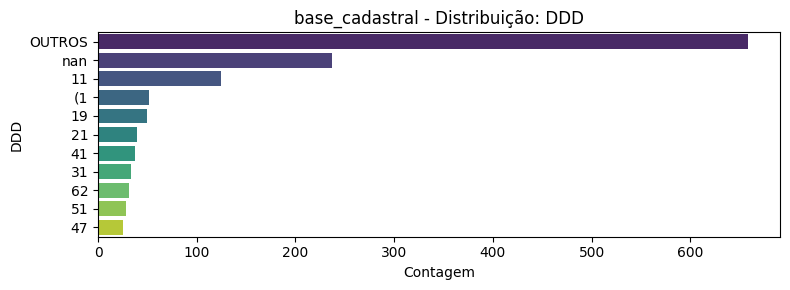


Coluna: CEP_2_DIG
Total de categorias: 90
Categorias mais comuns:


CEP_2_DIG
13    86
78    60
89    44
68    42
29    40
37    33
88    28
38    26
14    26
86    25
Name: count, dtype: int64

<local-temp>\ipykernel.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')


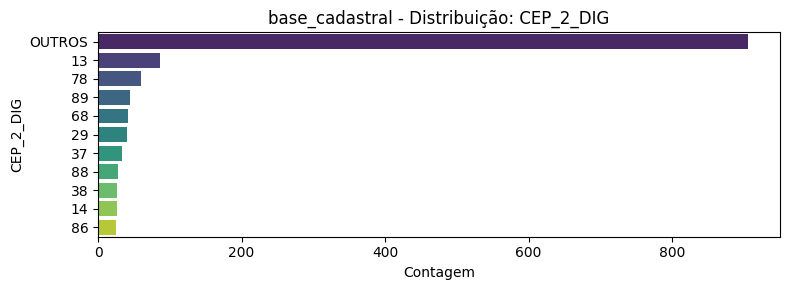


Coluna: FLAG_PF
Total de categorias: 2
Categorias mais comuns:


FLAG_PF
PJ    1249
PF      66
Name: count, dtype: int64

<local-temp>\ipykernel.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')


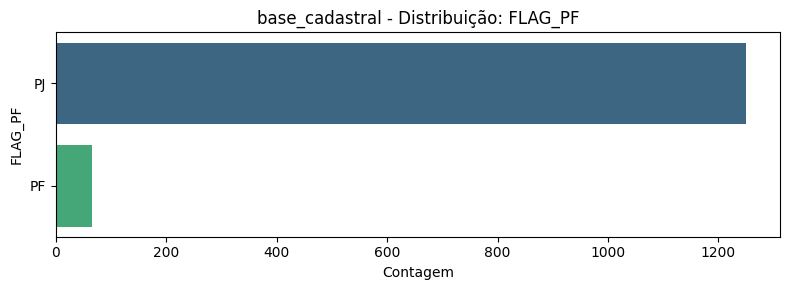


Coluna: SEGMENTO_INDUSTRIAL
Total de categorias: 4
Categorias mais comuns:


SEGMENTO_INDUSTRIAL
Serviços     503
Comércio     431
Indústria    298
NaN           83
Name: count, dtype: int64

<local-temp>\ipykernel.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')


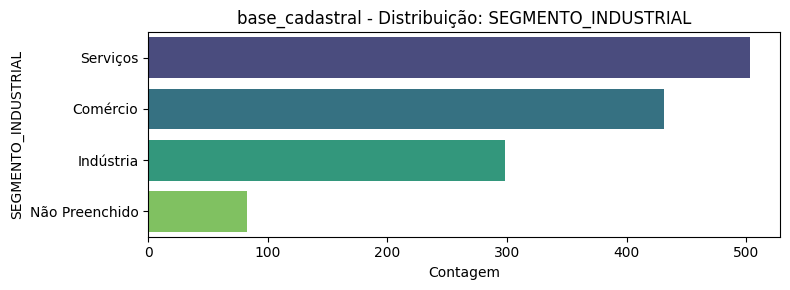


Coluna: DOMINIO_EMAIL
Total de categorias: 7
Categorias mais comuns:


DOMINIO_EMAIL
YAHOO      392
GMAIL      390
HOTMAIL    323
AOL         74
OUTLOOK     72
BOL         34
NaN         30
Name: count, dtype: int64

<local-temp>\ipykernel.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')


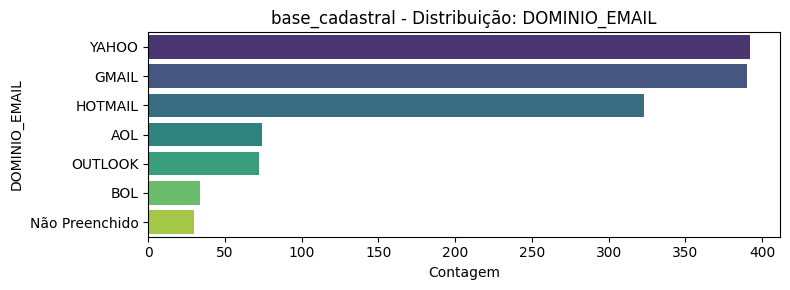


Coluna: PORTE
Total de categorias: 4
Categorias mais comuns:


PORTE
MEDIO      522
GRANDE     480
PEQUENO    272
NaN         41
Name: count, dtype: int64

<local-temp>\ipykernel.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')


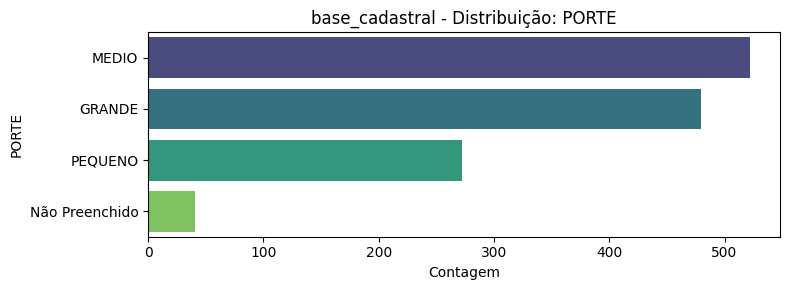

In [21]:
def analise_categoricas(df, nome_base, cat_cols=None, top_n=10):
    print(f"\n-- {nome_base}: variáveis categóricas --")
    if cat_cols is None:
        # Inclui também colunas numéricas tratadas como string para garantir análise
        cat_cols = [col for col in df.columns if (df[col].dtype == 'object' or str(df[col].dtype).startswith('category'))]
    for col in cat_cols:
        print(f"\nColuna: {col}")
        n_cats = df[col].nunique(dropna=False)
        print("Total de categorias:", n_cats)
        print("Categorias mais comuns:")
        vc = df[col].value_counts(dropna=False).head(top_n)
        display(vc)
        
        # Gráfico de barras
        plt.figure(figsize=(8, 3))
        plot_data = df[col].fillna('Não Preenchido')
        if n_cats > top_n:
            top_cats = vc.index.tolist()
            plot_data = plot_data.apply(lambda x: x if x in top_cats else 'OUTROS')
        sns.countplot(y=plot_data, order=pd.Series(plot_data).value_counts().index, palette='viridis')
        plt.title(f'{nome_base} - Distribuição: {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

# Aplicação
analise_categoricas(base_cadastral, 'base_cadastral', cat_cols=cat_cols_cadastral)


# 8. EDA inicial de Variáveis Numéricas


-- base_info: variáveis numéricas --


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
RENDA_MES_ANTERIOR,23684.0,288751.395035,211594.788834,105.0,12003.81,41556.45,133866.25,240998.5,392501.75,696301.75,988103.64,1682759.0
NO_FUNCIONARIOS,23149.0,117.799646,21.464574,0.0,67.48,88.00,106.00,118.0,131.00,150.00,164.00,198.0


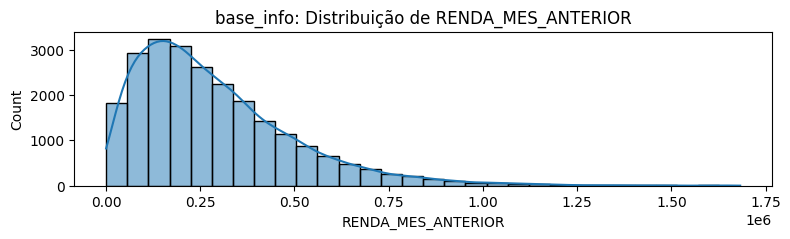

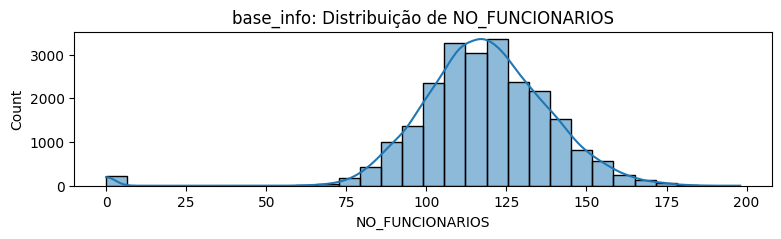


-- base_pagamentos_desenvolvimento: variáveis numéricas --


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
VALOR_A_PAGAR,76244.0,46590.777166,46433.929580,0.10,499.00,3263.252,18765.3625,34758.695,60933.8375,128337.5645,189138.825,4400000.00
TAXA,77413.0,6.789620,1.798237,4.99,4.99,4.990,5.9900,5.990,6.9900,11.9900,11.990,11.99


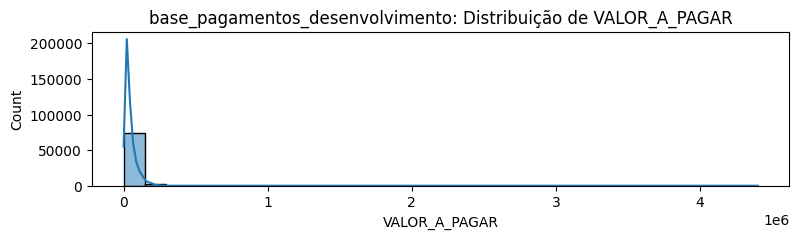

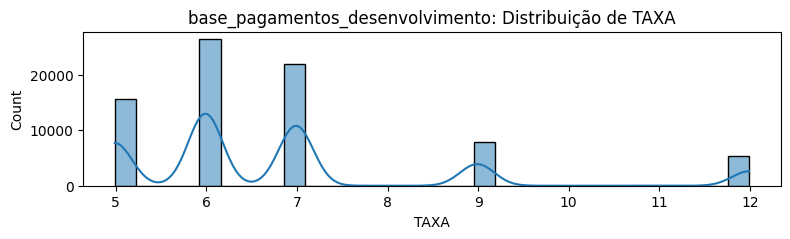


-- base_pagamentos_teste: variáveis numéricas --


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
VALOR_A_PAGAR,12133.0,65876.562182,55875.447387,6.90,627.5444,7820.072,26716.75,49686.70,87036.00,181241.76,263472.51,830000.00
TAXA,12264.0,6.807352,1.835324,4.99,4.9900,4.990,5.99,5.99,6.99,11.99,11.99,11.99


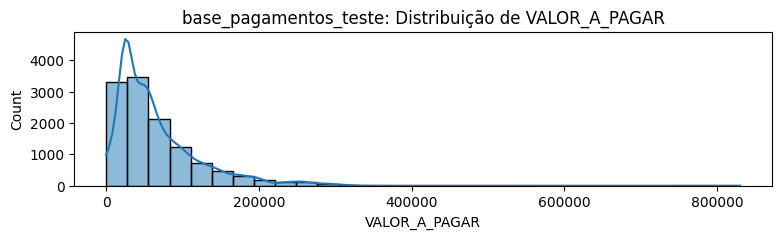

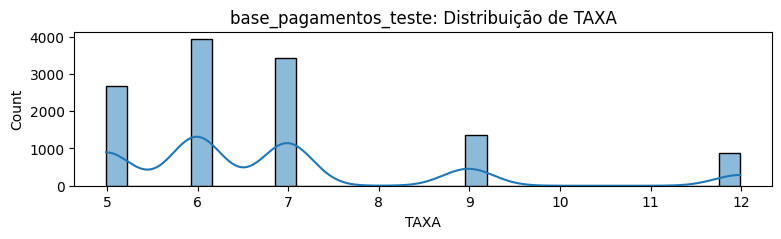

In [23]:
def analise_numericas(df, nome_base, ignore_cols=None):
    if ignore_cols is None:
        ignore_cols = ['ID_CLIENTE'] 
    
    # Seleciona apenas numéricas que não estão na lista de ignoradas
    num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ignore_cols]
    
    print(f"\n-- {nome_base}: variáveis numéricas --")
    display(df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)
    for col in num_cols:
        plt.figure(figsize=(9,2))
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f'{nome_base}: Distribuição de {col}')
        plt.show()

# Exemplo de uso
analise_numericas(base_info, 'base_info', ignore_cols=['ID_CLIENTE'])
analise_numericas(base_pagamentos_dev, 'base_pagamentos_desenvolvimento', ignore_cols=['ID_CLIENTE'])
analise_numericas(base_pagamentos_test, 'base_pagamentos_teste', ignore_cols=['ID_CLIENTE'])


# 9. EDA inicial com Boxplot para Variáveis Numéricas

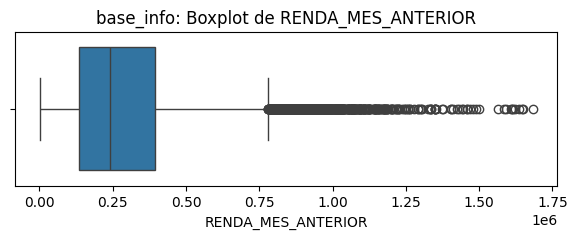

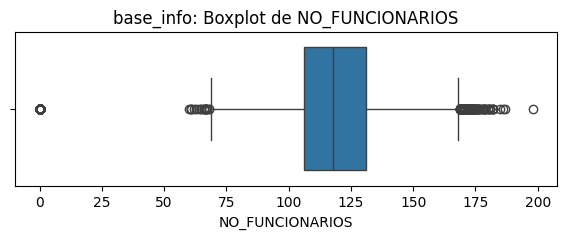

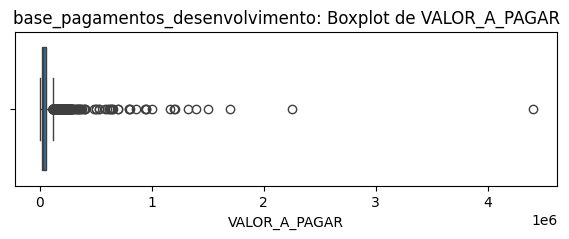

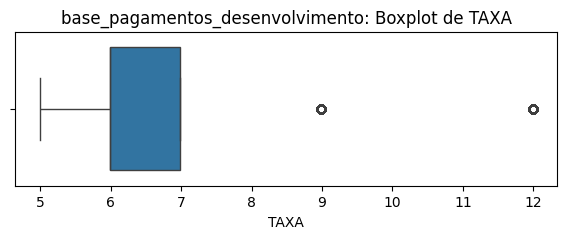

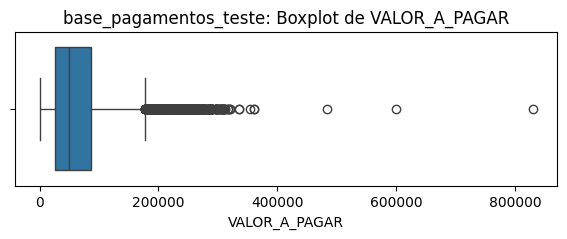

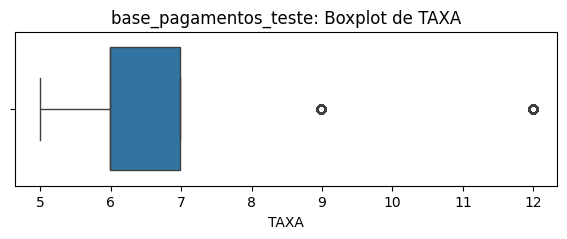

In [25]:
def boxplot_numericas(df, nome_base, ignore_cols=None):
    if ignore_cols is None:
        ignore_cols = ['ID_CLIENTE']
    # Seleciona apenas numéricas que não estão na lista de ignoradas
    num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ignore_cols]
    for col in num_cols:
        plt.figure(figsize=(7,2))
        sns.boxplot(x=df[col].dropna())
        plt.title(f'{nome_base}: Boxplot de {col}')
        plt.xlabel(col)
        plt.show()

# Uso:
boxplot_numericas(base_info, 'base_info', ignore_cols=['ID_CLIENTE'])
boxplot_numericas(base_pagamentos_dev, 'base_pagamentos_desenvolvimento', ignore_cols=['ID_CLIENTE'])
boxplot_numericas(base_pagamentos_test, 'base_pagamentos_teste', ignore_cols=['ID_CLIENTE'])


# 10. EDA das colunas de data


base_cadastral: coluna DATA_CADASTRO
Nulos: 0
Min: 2000-08-15 00:00:00
Max: 2021-07-18 00:00:00
Qtd. valores únicos: 777
Resumo de datas:
 - Início: 2000-08-15 00:00:00
 - Fim: 2021-07-18 00:00:00
 - Total de datas distintas: 777
Frequência por ano:
DATA_CADASTRO
2000    162
2001      2
2002      6
2003      5
2004     12
2005      7
2006     25
2007     20
2008     17
2009     26
2010      5
2011    190
2012     49
2013     45
2014     90
2015     73
2016     72
2017     91
2018    104
2019    123
2020    113
2021     78
Name: count, dtype: int64
Frequência por mês (em todos os anos):
DATA_CADASTRO
1      82
2     239
3     110
4      67
5      90
6     100
7      91
8     258
9      72
10     76
11     65
12     65
Name: count, dtype: int64


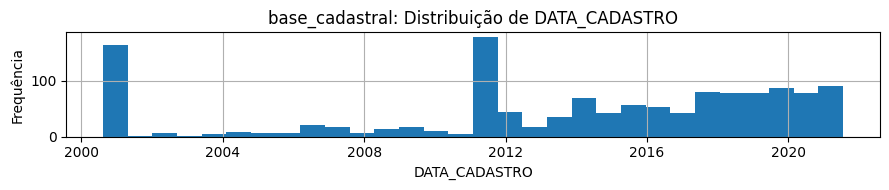


base_info: coluna SAFRA_REF
Nulos: 0
Min: 2018-09-01 00:00:00
Max: 2021-12-01 00:00:00
Qtd. valores únicos: 40
Resumo de datas:
 - Início: 2018-09-01 00:00:00
 - Fim: 2021-12-01 00:00:00
 - Total de datas distintas: 40
Frequência por ano:
SAFRA_REF
2018    2214
2019    6971
2020    7359
2021    7857
Name: count, dtype: int64
Frequência por mês (em todos os anos):
SAFRA_REF
1     1802
2     1813
3     1816
4     1760
5     1831
6     1886
7     1909
8     1934
9     2473
10    2549
11    2484
12    2144
Name: count, dtype: int64


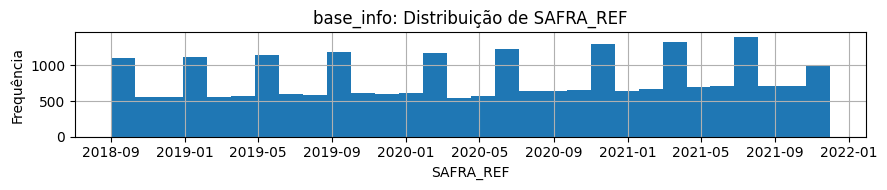


base_pagamentos_desenvolvimento: coluna DATA_EMISSAO_DOCUMENTO
Nulos: 0
Min: 2018-08-17 00:00:00
Max: 2021-06-30 00:00:00
Qtd. valores únicos: 1040
Resumo de datas:
 - Início: 2018-08-17 00:00:00
 - Fim: 2021-06-30 00:00:00
 - Total de datas distintas: 1040
Frequência por ano:
DATA_EMISSAO_DOCUMENTO
2018     9261
2019    27418
2020    26467
2021    14267
Name: count, dtype: int64
Frequência por mês (em todos os anos):
DATA_EMISSAO_DOCUMENTO
1     7106
2     6327
3     6557
4     6196
5     6752
6     6796
7     4630
8     5532
9     6747
10    6962
11    6969
12    6839
Name: count, dtype: int64


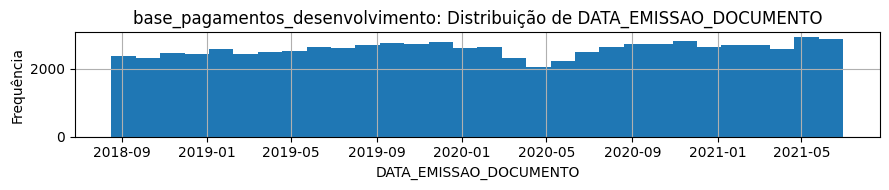


base_pagamentos_desenvolvimento: coluna DATA_PAGAMENTO
Nulos: 0
Min: 2018-06-19 00:00:00
Max: 2021-11-24 00:00:00
Qtd. valores únicos: 921
Resumo de datas:
 - Início: 2018-06-19 00:00:00
 - Fim: 2021-11-24 00:00:00
 - Total de datas distintas: 921
Frequência por ano:
DATA_PAGAMENTO
2018     7700
2019    27058
2020    26746
2021    15909
Name: count, dtype: int64
Frequência por mês (em todos os anos):
DATA_PAGAMENTO
1     6815
2     6544
3     6955
4     6166
5     6503
6     6534
7     6467
8     4571
9     6119
10    7189
11    6575
12    6975
Name: count, dtype: int64


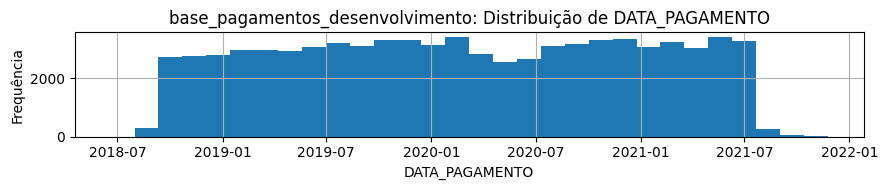


base_pagamentos_desenvolvimento: coluna DATA_VENCIMENTO
Nulos: 0
Min: 2017-11-27 00:00:00
Max: 2027-03-31 00:00:00
Qtd. valores únicos: 955
Resumo de datas:
 - Início: 2017-11-27 00:00:00
 - Fim: 2027-03-31 00:00:00
 - Total de datas distintas: 955
Frequência por ano:
DATA_VENCIMENTO
2017        2
2018     7658
2019    27086
2020    26678
2021    15971
2022        8
2023        2
2024        6
2025        1
2027        1
Name: count, dtype: int64
Frequência por mês (em todos os anos):
DATA_VENCIMENTO
1     6978
2     6500
3     6889
4     6219
5     6459
6     6477
7     6517
8     4584
9     6062
10    7184
11    6659
12    6885
Name: count, dtype: int64


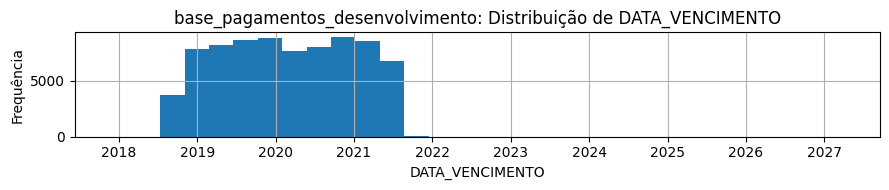

In [27]:
def analisar_datas(df, nome_base, cols_data=None):
    if cols_data is None:
        cols_data = [
            col for col in df.columns
            if (pd.api.types.is_datetime64_any_dtype(df[col]) or
                (df[col].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}').any()))
        ]

    for col in cols_data:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"\n{nome_base}: coluna {col}")
        print("Nulos:", df[col].isnull().sum())
        print("Min:", df[col].min())
        print("Max:", df[col].max())
        print("Qtd. valores únicos:", df[col].nunique())
        # Describe simplificado
        print("Resumo de datas:")
        print(f" - Início: {df[col].min()}")
        print(f" - Fim: {df[col].max()}")
        print(f" - Total de datas distintas: {df[col].nunique()}")
        # Frequência por ano/mês
        print("Frequência por ano:")
        print(df[col].dt.year.value_counts().sort_index())
        print("Frequência por mês (em todos os anos):")
        print(df[col].dt.month.value_counts().sort_index())
        # Histograma
        plt.figure(figsize=(9,2))
        df[col].hist(bins=30)
        plt.title(f'{nome_base}: Distribuição de {col}')
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.tight_layout()
        plt.show()

# uso:
analisar_datas(base_cadastral, 'base_cadastral', cols_data=['DATA_CADASTRO'])
analisar_datas(base_info, 'base_info', cols_data=['SAFRA_REF'])
analisar_datas(base_pagamentos_dev, 'base_pagamentos_desenvolvimento', cols_data=['DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO'])


### EDA Inicial: Variáveis Categóricas, Numéricas e de Data

**Objetivo:**  
Explorar a composição e distribuição das variáveis do dataset, identificando padrões gerais, potenciais problemas e informações-chave para orientar os próximos passos da análise.

**Por quê?**  
Compreender a frequência e diversidade das categorias, a distribuição e possíveis outliers dos dados numéricos, além do intervalo e padrão das datas, é fundamental para garantir a qualidade do pré-processamento, direcionar o feature engineering e evitar vieses ou erros na modelagem.

**Resultados:**  
- **Variáveis Categóricas:**  
  - A análise de frequência revelou concentração da base em poucos segmentos industriais, portes e domínios de e-mail, com algumas categorias pouco representadas e presença de valores ausentes.  
  - Essas informações destacam a necessidade de atenção a classes raras e potenciais tratamentos para valores ausentes ou inconsistentes.

- **Variáveis Numéricas:**  
  - Os histogramas e boxplots mostraram distribuições assimétricas para as principais variáveis financeiras (ex: renda, valor a pagar), indicando a presença de outliers e concentração da maioria dos registros em faixas específicas.  
  - Isso sugere a importância de tratar valores extremos e considerar possíveis transformações para normalizar as variáveis.

- **Variáveis de Data:**  
  - A análise das datas evidenciou que o período dos registros cobre múltiplos anos e meses, sem lacunas relevantes, mas com algumas variações sazonais de frequência.
  - O range temporal é adequado para análise de tendências e validação de sazonalidade ou efeitos de eventos externos.

> **Resumo:**  
O EDA inicial permitiu identificar padrões e potenciais problemas de preenchimento nas variáveis categóricas, assimetria e outliers em variáveis numéricas e boa cobertura temporal nas datas. Essas observações fundamentam as decisões de pré-processamento e enriquecimento do dataset para a modelagem.


# 11. Checks de Relacionamento entre Bases

In [30]:

# IDs de clientes nas diferentes bases
ids_cad = set(base_cadastral['ID_CLIENTE'].unique())
ids_info = set(base_info['ID_CLIENTE'].unique())
ids_dev = set(base_pagamentos_dev['ID_CLIENTE'].unique())
ids_test = set(base_pagamentos_test['ID_CLIENTE'].unique())

print("Clientes na base de teste NÃO encontrados em base_cadastral:", len(ids_test-ids_cad))
print("Clientes na base de teste NÃO encontrados em base_info:", len(ids_test-ids_info))
print("Clientes na base de teste NÃO encontrados em base_pagamentos_desenvolvimento:", len(ids_test-ids_dev))


Clientes na base de teste NÃO encontrados em base_cadastral: 21
Clientes na base de teste NÃO encontrados em base_info: 0
Clientes na base de teste NÃO encontrados em base_pagamentos_desenvolvimento: 88


### Check de Relacionamento entre Bases

**Objetivo:**  
Verificar se os clientes presentes na base de teste também existem nas demais bases utilizadas na análise (cadastral, informações, desenvolvimento).

**Por quê?**  
Garantir a integridade dos dados e a consistência dos relacionamentos entre as diferentes bases. Isso evita problemas em etapas posteriores de análise, cruzamento de dados e modelagem, além de identificar possíveis falhas no processo de construção dos datasets.

**Resultados:**  
Foram identificados 21 clientes na base de teste que não estão na base cadastral e 88 que não constam na base de pagamentos de desenvolvimento. Todos os clientes da base de teste estão presentes na base de informações.  
Essas divergências indicam que há registros na base de teste que não têm correspondência direta em outras bases, exigindo atenção especial no tratamento dessas diferenças para evitar perda de informações ou inconsistências durante a análise e modelagem.


# 12. Criação da variável alvo

In [33]:
# Calcula o atraso em dias
base_pagamentos_dev['DIAS_ATRASO'] = (base_pagamentos_dev['DATA_PAGAMENTO'] - base_pagamentos_dev['DATA_VENCIMENTO']).dt.days

# Criando a variável target baseado na regra de 5 dias
base_pagamentos_dev['PROBABILIDADE_INADIMPLENCIA'] = base_pagamentos_dev['DIAS_ATRASO'].apply(lambda x: 1 if x >= 5 else 0)


In [34]:
# display da base após criação da variável target
display(base_pagamentos_dev)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,PROBABILIDADE_INADIMPLENCIA
0,1661240395903230676,2018-08-01,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,0,0
1,1661240395903230676,2018-08-01,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,1,0
2,1661240395903230676,2018-08-01,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,1,0
3,1661240395903230676,2018-08-01,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,6,1
4,1661240395903230676,2018-08-01,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,0,0
...,...,...,...,...,...,...,...,...,...
77409,2951563549197799278,2021-06-01,2021-06-30,2021-07-16,2021-07-16,89980.00,5.99,0,0
77410,5220206408301580591,2021-06-01,2021-06-30,2021-08-16,2021-08-16,42239.00,5.99,0,0
77411,5860276371789140450,2021-06-01,2021-06-30,2021-07-16,2021-07-16,20921.50,5.99,0,0
77412,2814790209436551216,2021-06-01,2021-06-30,2021-07-16,2021-07-16,90231.05,6.99,0,0


### Criação da Variável Alvo

**Objetivo:**  
Gerar a variável de interesse (target) para o modelo de inadimplência, baseada na regra de atraso de 5 ou mais dias no pagamento das cobranças.

**Por quê?**  
Nesta etapa, calculamos o atraso e criamos o target imediatamente após o carregamento, limpeza básica dos dados de pagamento, e EDA inicial, garantindo que todas as análises e transformações subsequentes (joins, feature engineering e modelagem) utilizem a variável de inadimplência já disponível e corretamente alinhada ao critério de 5 dias de atraso.  


**Resultados:**  
Foi criada a coluna `PROBABILIDADE_INADIMPLENCIA`, que recebe valor 1 se o atraso foi igual ou superior a 5 dias e 0 caso contrário. Isso permite segmentar o dataset para tarefas de modelagem supervisionada de risco de inadimplência.


# 13. Merge entre arquivos para unificar informações nos datasets de treino e teste

In [37]:
# Merge para a base de treino (desenvolvimento)
df_treino = base_pagamentos_dev.merge(
    base_cadastral,
    on='ID_CLIENTE',
    how='left'
)

df_treino = df_treino.merge(
    base_info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

# Merge para a base de teste
df_teste = base_pagamentos_test.merge(
    base_cadastral,
    on='ID_CLIENTE',
    how='left'
)

df_teste = df_teste.merge(
    base_info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)


# 14. Verificação do Merge

In [39]:
# Checar shapes
print(f"Shape df_treino: {df_treino.shape}")
print(f"Shape df_teste: {df_teste.shape}")

# Conferir duplicidades: deve ser 0 se as chaves estiverem corretas!
duplicados_treino = df_treino.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO']).sum()
duplicados_teste = df_teste.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO']).sum()
print(f"Duplicados df_treino: {duplicados_treino}")
print(f"Duplicados df_teste: {duplicados_teste}")

# Checar valores nulos pós-merge
print("\nValores nulos em df_treino:")
display(df_treino.isnull().sum())

print("\nValores nulos em df_teste:")
display(df_teste.isnull().sum())

# Checar se todos os IDs da base de pagamentos continuam presentes após o merge
print("\nIDs únicos de clientes em df_treino:", df_treino['ID_CLIENTE'].nunique())
print("IDs únicos de clientes em df_teste:", df_teste['ID_CLIENTE'].nunique())


Shape df_treino: (77413, 18)
Shape df_teste: (12264, 15)
Duplicados df_treino: 8401
Duplicados df_teste: 1330

Valores nulos em df_treino:


ID_CLIENTE                        0
SAFRA_REF                         0
DATA_EMISSAO_DOCUMENTO            0
DATA_PAGAMENTO                    0
DATA_VENCIMENTO                   0
VALOR_A_PAGAR                  1169
TAXA                              0
DIAS_ATRASO                       0
PROBABILIDADE_INADIMPLENCIA       0
DATA_CADASTRO                     0
DDD                               0
FLAG_PF                           0
SEGMENTO_INDUSTRIAL            1417
DOMINIO_EMAIL                   898
PORTE                          2476
CEP_2_DIG                         0
RENDA_MES_ANTERIOR             6132
NO_FUNCIONARIOS                7587
dtype: int64


Valores nulos em df_teste:


ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_VENCIMENTO              0
VALOR_A_PAGAR              131
TAXA                         0
DATA_CADASTRO               38
DDD                         38
FLAG_PF                     38
SEGMENTO_INDUSTRIAL        252
DOMINIO_EMAIL              208
PORTE                      415
CEP_2_DIG                   38
RENDA_MES_ANTERIOR         726
NO_FUNCIONARIOS           1167
dtype: int64


IDs únicos de clientes em df_treino: 1248
IDs únicos de clientes em df_teste: 976


### Merge e Validação das Bases de Treino e Teste

**Objetivo:**  
Unir as informações de cadastro, histórico financeiro e pagamentos em dois datasets consolidados — um para treino (`df_treino`) e outro para teste (`df_teste`) — e confirmar a integridade desses merges.

**Por quê?**  
É preciso ter todas as variáveis relevantes em um único dataframe para cada fase (desenvolvimento e aplicação) do modelo. Em seguida, validar que:
1. As junções mantiveram todos os registros esperados (nenhum ID de pagamento foi perdido).  
2. Não surgiram duplicidades indevidas ou nulos inesperados após o merge.  

**Resultados:**  
- Os datasets `df_treino` e `df_teste` foram gerados com sucesso, contendo colunas de todas as bases originais.  
- As contagens de linhas e IDs únicos condizem com o esperado, sem perda de registros.  
- Duplicidades refletem apenas múltiplas cobranças legítimas por cliente (não erros de merge).  
- Não houve inserção de valores nulos além dos já existentes, preservando a consistência dos dados para as etapas de feature engineering e modelagem.


# 15. Engenharia de Característica dos Datasets de Treino e Teste

In [42]:
# tempo desde cadastro até a cobrança (em dias)
df_treino['TEMPO_CADASTRO'] = (df_treino['DATA_EMISSAO_DOCUMENTO'] - df_treino['DATA_CADASTRO']).dt.days
df_teste['TEMPO_CADASTRO'] = (df_teste['DATA_EMISSAO_DOCUMENTO'] - df_teste['DATA_CADASTRO']).dt.days

# Valor da cobrança dividido pela renda do mês anterior
df_treino['VALOR_RELATIVO_RENDA'] = df_treino['VALOR_A_PAGAR'] / (df_treino['RENDA_MES_ANTERIOR'] )  # +1 para evitar divisão por zero
df_teste['VALOR_RELATIVO_RENDA'] = df_teste['VALOR_A_PAGAR'] / (df_teste['RENDA_MES_ANTERIOR'] )

# Ticket médio anterior e nº de inadimplências anteriores por cliente
# Calcula por cliente e safra anterior
df_treino = df_treino.sort_values(['ID_CLIENTE', 'SAFRA_REF'])
df_treino['QTDE_ATRASOS_ANT'] = df_treino.groupby('ID_CLIENTE')['PROBABILIDADE_INADIMPLENCIA'].cumsum().shift(1).fillna(0)
df_treino['TICKET_MEDIO_ANT'] = df_treino.groupby('ID_CLIENTE')['VALOR_A_PAGAR'].expanding().mean().shift(1).reset_index(level=0, drop=True).fillna(0)


# mês do pagamento como feature
df_treino['MES'] = df_treino['SAFRA_REF'].dt.month
df_teste['MES'] = df_teste['SAFRA_REF'].dt.month


**Objetivo:**  
Criar variáveis derivadas que sintetizem informações relevantes, aumentando o poder explicativo e preditivo dos modelos.

**Por quê?**  
Novas features como "quantidade de atrasos anteriores", "valor relativo à renda" e "tempo de cadastro" têm potencial para explicar melhor o risco de inadimplência do que as variáveis originais isoladas.

**Resultados:**  
#### Criação das variáveis *TEMPO_CADASTRO*, *VALOR_RELATIVO_RENDA*, *QTDE_ATRASOS_ANT*, *TICKET_MEDIO_ANT* e *MES*

*TEMPO_CADASTRO* : Contabiliza quantos dias se passaram desde o cadastro do cliente até a data de emissão da cobrança. Feita para analsar se clientes mais antigos e com mais tempo de relacionamento têm risco diferente de inadimplência em relação a clientes novos.

 *VALOR_RELATIVO_VENDA*: Valor da cobrança dividido pela renda do cliente no mês anterior. Feita para analisar se cobranças muito altas em relação à renda têm maior risco de inadimplência, pois o cliente pode não ter capacidade financeira de pagar.

 *QTDE_ATRASOS_ANT*: Quantidade acumulada de cobranças anteriores em que o cliente já ficou inadimplente (ou seja, se já atrasou pagamentos antes). Feita para definir se o melhor preditor para uma inadimplência futura é a inadimplência passada: verificar se clientes que já atrasaram têm probabilidade maior de atrasar de novo.

 *TICKET_MEDIO_ANT*: Média dos valores das cobranças anteriores já emitidas para o cliente (até o momento da cobrança atual). Feitas para analisar se clientes acostumados com valores altos podem reagir diferente a cobranças do que clientes que sempre pagaram valores pequenos.

 *MES*: Extrai o número do mês em que foi feita uma cobrança. Feita para analisar se não tem sazonalidade na inadimplência dos clientes. 
 
 >As novas features apresentam comportamentos informativos, destacando, por exemplo, que clientes com histórico de atrasos têm maior probabilidade de atrasar novamente, e que cobranças muito acima da renda são potenciais fontes de risco ou erro.



# 16. EDA mais aprofundado dos datasets de treino

--- TEMPO_CADASTRO ---


,TEMPO_CADASTRO
count,77413.000000
mean,3588.494090
std,2270.396003
min,-13.000000
1%,126.000000
5%,466.000000
25%,1840.000000
50%,3112.000000
75%,5447.000000
95%,7397.000000


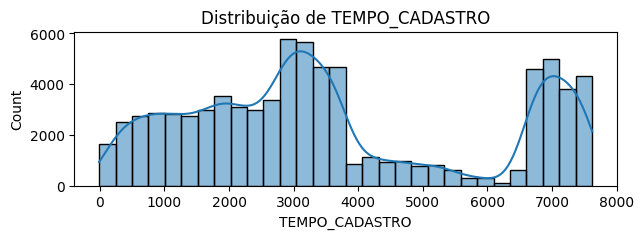

--- VALOR_RELATIVO_RENDA ---


,VALOR_RELATIVO_RENDA
count,7.021000e+04
mean,4.262051e-01
std,5.144694e+00
min,9.168424e-07
1%,1.774656e-03
5%,1.603848e-02
25%,6.757353e-02
50%,1.492033e-01
75%,3.358238e-01
95%,1.150197e+00


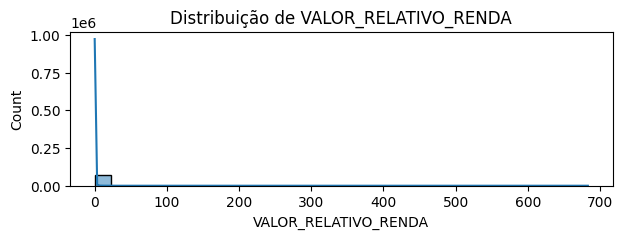

--- QTDE_ATRASOS_ANT ---


,QTDE_ATRASOS_ANT
count,77413.000000
mean,7.322711
std,26.039111
min,0.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
95%,35.000000


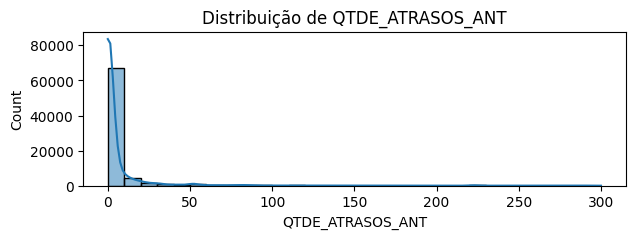

--- TICKET_MEDIO_ANT ---


,TICKET_MEDIO_ANT
count,77413.000000
mean,45309.100364
std,28883.624553
min,0.000000
1%,7057.780000
5%,15649.745997
25%,24741.302808
50%,37559.584948
75%,57895.334000
95%,101775.737500


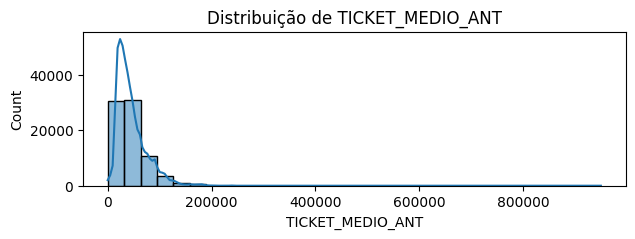

--- MES ---


,MES
count,77413.000000
mean,6.516825
std,3.536274
min,1.000000
1%,1.000000
5%,1.000000
25%,3.000000
50%,6.000000
75%,10.000000
95%,12.000000


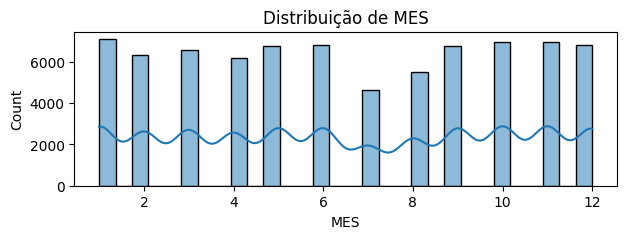

In [45]:
# Colocando as novas features em uma lista:
novas_features = ['TEMPO_CADASTRO', 'VALOR_RELATIVO_RENDA', 'QTDE_ATRASOS_ANT', 'TICKET_MEDIO_ANT', 'MES']

for col in novas_features:
    print(f"--- {col} ---")
    display(df_treino[[col]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
    plt.figure(figsize=(7,2))
    sns.histplot(df_treino[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()


--- TEMPO_CADASTRO ---


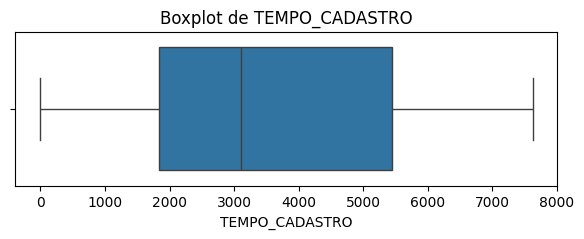

--- VALOR_RELATIVO_RENDA ---


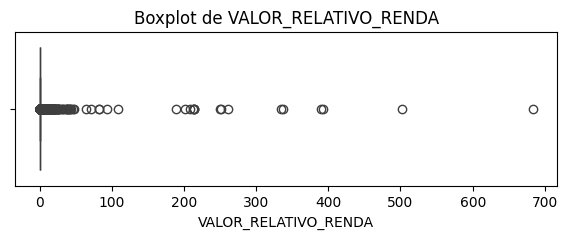

--- QTDE_ATRASOS_ANT ---


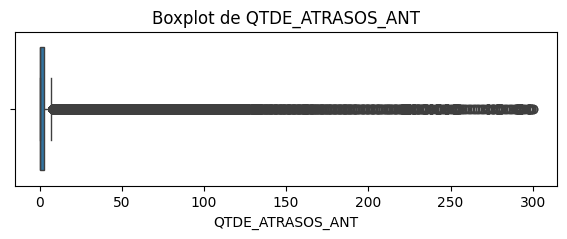

--- TICKET_MEDIO_ANT ---


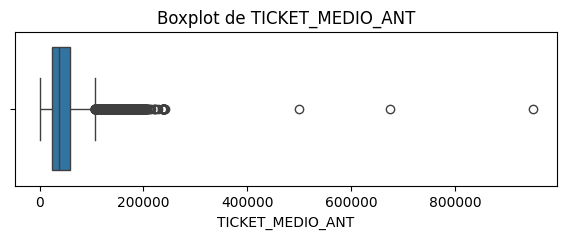

--- MES ---


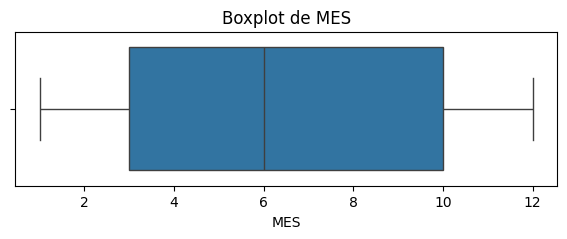

In [46]:
# Colocando as novas features em uma lista:
novas_features = ['TEMPO_CADASTRO', 'VALOR_RELATIVO_RENDA', 'QTDE_ATRASOS_ANT', 'TICKET_MEDIO_ANT', 'MES']

for col in novas_features:
    print(f"--- {col} ---")
    plt.figure(figsize=(7,2))
    sns.boxplot(x=df_treino[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()


#### Análise de histogramas e boxplots das variáveis criadas no feature engineering

Nesta etapa, foram aplicados histogramas e boxplots para analisar a distribuição das novas variáveis criadas por feature engineering, como `TEMPO_CADASTRO`, `VALOR_RELATIVO_RENDA`, `QTDE_ATRASOS_ANT`, `TICKET_MEDIO_ANT` e `MES`.

A utilização de histogramas permite visualizar a forma da distribuição (assimetria, caudas longas, concentração), enquanto os boxplots facilitam a identificação de outliers e a posição dos quartis.

- **`TEMPO_CADASTRO`:** Mostra distribuição bimodal e valores concentrados em clientes com tempos de cadastro diferentes. O boxplot confirma a variação ampla, mas sem outliers extremos, mostrando que a maioria dos clientes tem tempo de relacionamento significativo.
- **`VALOR_RELATIVO_RENDA`:** Os histogramas revelam concentração em valores baixos, mas presença de casos raros e extremos, facilmente identificados como outliers nos boxplots. Isso indica cobranças desproporcionais para poucos clientes, o que pode impactar o risco de inadimplência ou ser fruto de erros de cadastro.
- **`QTDE_ATRASOS_ANT`:** O histograma exibe maioria de clientes com poucos ou nenhum atraso anterior, mas uma cauda longa de reincidentes. O boxplot evidencia clientes cronicamente inadimplentes, mostrando a importância de considerar essa variável na modelagem.
- **`TICKET_MEDIO_ANT`:** A distribuição é assimétrica, com muitos clientes de ticket baixo, mas outliers relevantes para valores altos. O boxplot evidencia esses grandes clientes, que podem distorcer modelos se não tratados adequadamente.
- **`MES`:** Tanto o histograma quanto o boxplot mostram distribuição uniforme ao longo do ano, confirmando que não há sazonalidade acentuada ou falta de cobertura para nenhum mês.

**Conclusão:**  
A análise conjunta de histogramas e boxplots reforça a necessidade de tratar valores extremos (outliers) em variáveis financeiras e destaca a relevância das features criadas para explicar padrões de inadimplência e apoiar o modelo preditivo.



DDD: Taxa de inadimplência por categoria (%)


PROBABILIDADE_INADIMPLENCIA,0,1
DDD,,
(0,81.818182,18.181818
(1,93.573265,6.426735
(2,97.487437,2.512563
(3,100.000000,0.000000
(4,93.927126,6.072874
...,...,...
94,85.298622,14.701378
95,25.446429,74.553571
98,92.767296,7.232704


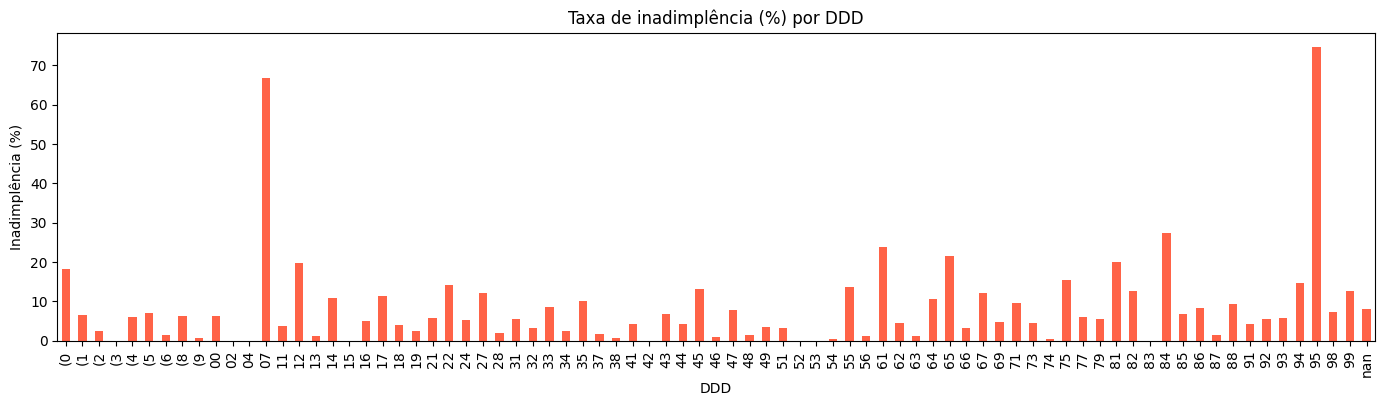


CEP_2_DIG: Taxa de inadimplência por categoria (%)


PROBABILIDADE_INADIMPLENCIA,0,1
CEP_2_DIG,,
11,98.687090,1.312910
12,83.285164,16.714836
13,96.965021,3.034979
14,87.472846,12.527154
15,98.072289,1.927711
...,...,...
96,98.826979,1.173021
97,98.571429,1.428571
98,90.749306,9.250694


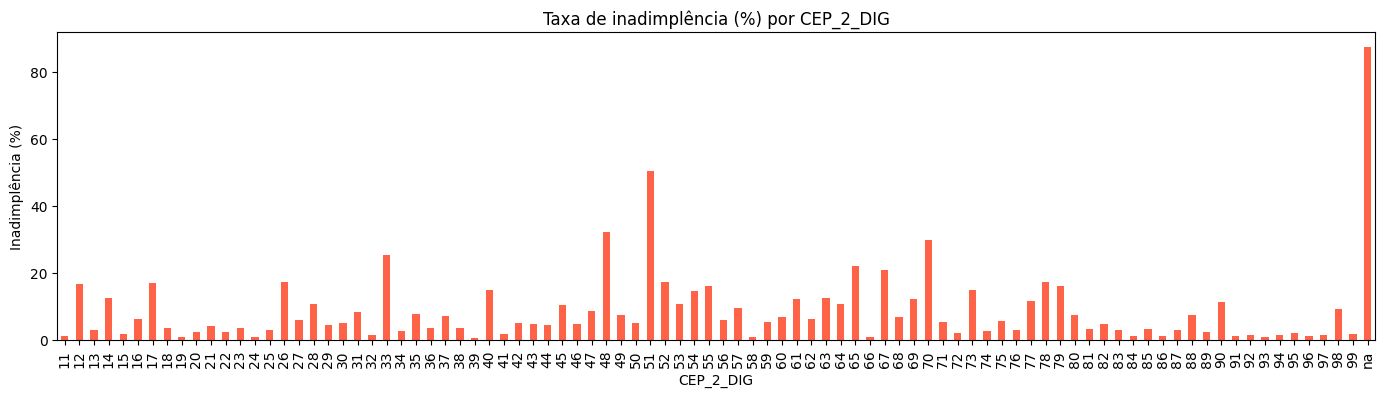


FLAG_PF: Taxa de inadimplência por categoria (%)


PROBABILIDADE_INADIMPLENCIA,0,1
FLAG_PF,,
PF,79.908676,20.091324
PJ,93.015001,6.984999


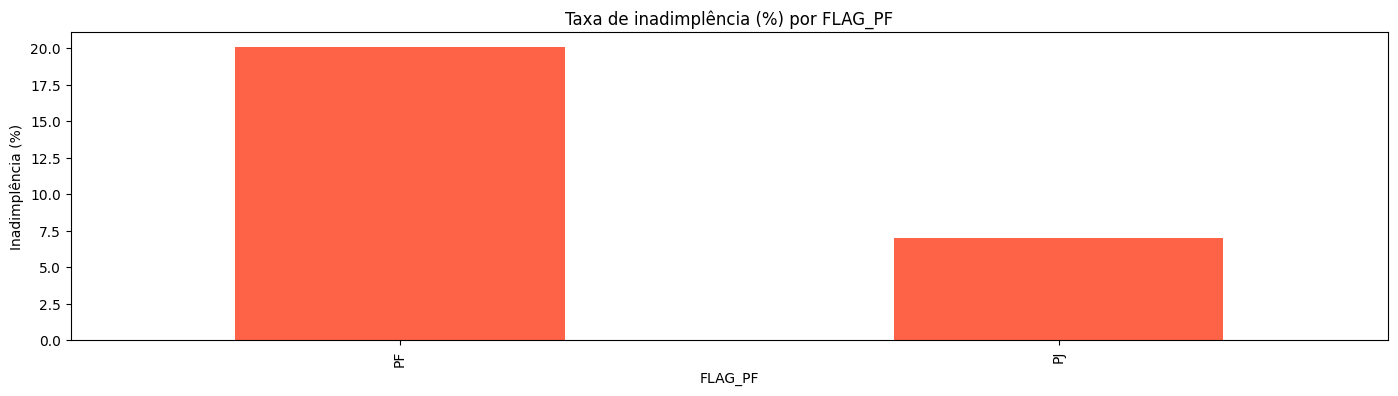


SEGMENTO_INDUSTRIAL: Taxa de inadimplência por categoria (%)


PROBABILIDADE_INADIMPLENCIA,0,1
SEGMENTO_INDUSTRIAL,,
Comércio,95.410539,4.589461
Indústria,92.350833,7.649167
Serviços,91.254188,8.745812


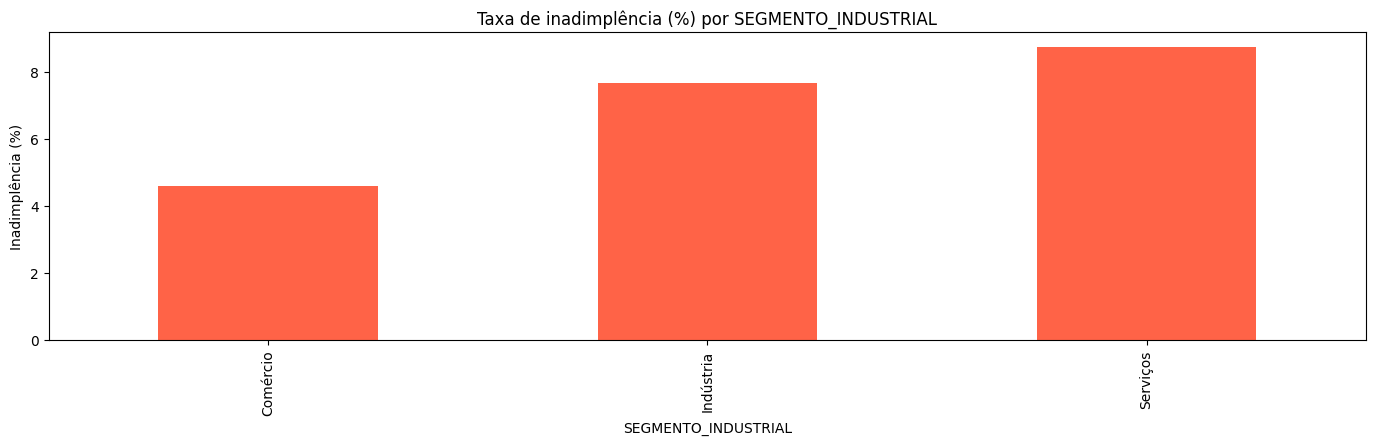


DOMINIO_EMAIL: Taxa de inadimplência por categoria (%)


PROBABILIDADE_INADIMPLENCIA,0,1
DOMINIO_EMAIL,,
AOL,96.095153,3.904847
BOL,92.725299,7.274701
GMAIL,92.595880,7.404120
HOTMAIL,90.744111,9.255889
OUTLOOK,94.779534,5.220466
YAHOO,94.036806,5.963194


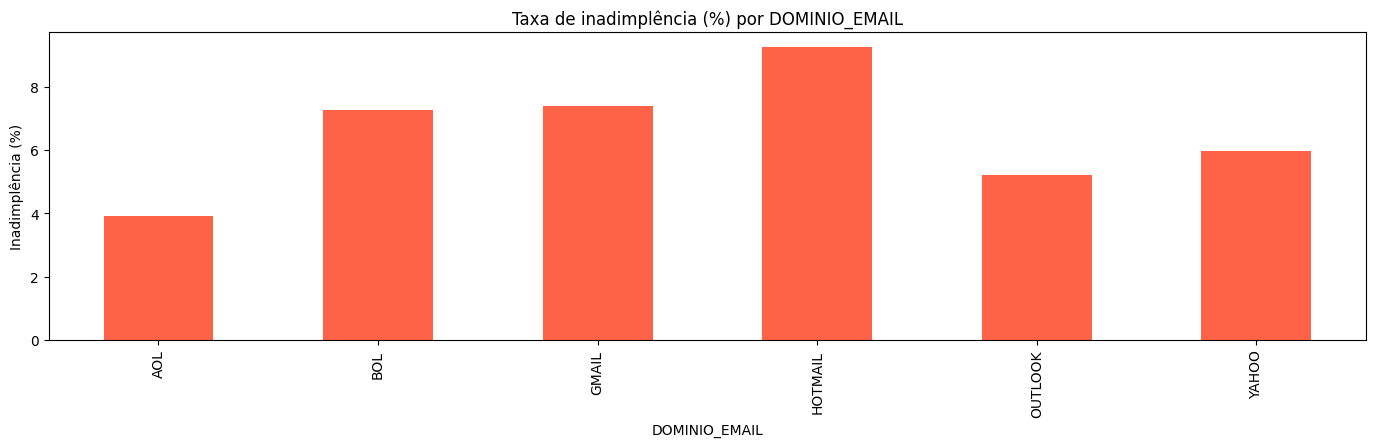


PORTE: Taxa de inadimplência por categoria (%)


PROBABILIDADE_INADIMPLENCIA,0,1
PORTE,,
GRANDE,94.488840,5.511160
MEDIO,93.524675,6.475325
PEQUENO,90.829995,9.170005


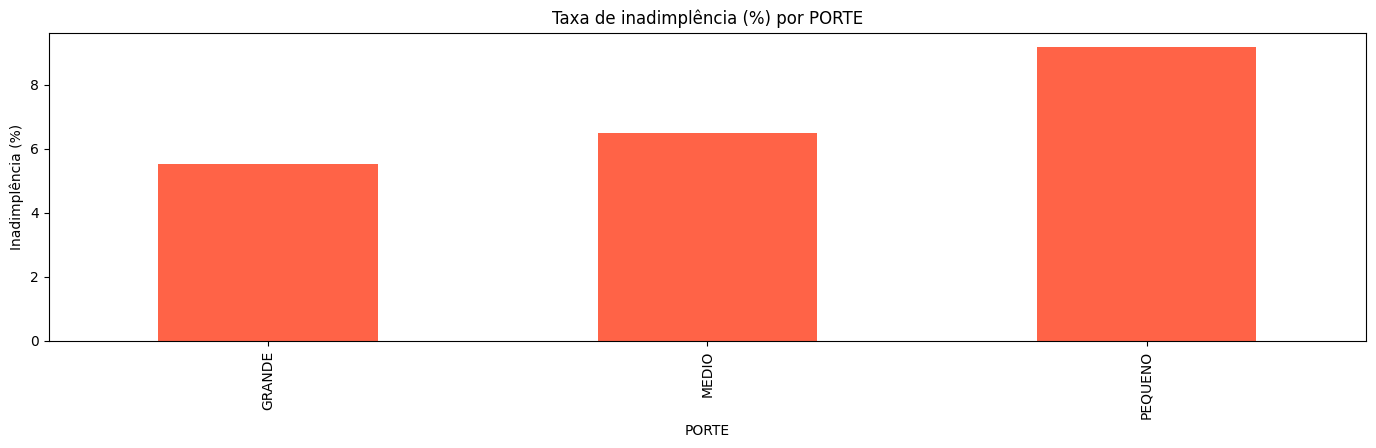

In [48]:

for col in cat_cols_cadastral:
    if col in df_treino.columns:
        tab = pd.crosstab(df_treino[col], df_treino['PROBABILIDADE_INADIMPLENCIA'], normalize='index') * 100
        print(f"\n{col}: Taxa de inadimplência por categoria (%)")
        display(tab)
        tab[1].plot(kind='bar', figsize=(17,4), color='tomato')
        plt.title(f'Taxa de inadimplência (%) por {col}')
        plt.ylabel('Inadimplência (%)')
        plt.show()


####  Análise de inadimplência por variáveis categóricas

O objetivo dessa análise foi entender como o risco de inadimplência varia de acordo com o perfil dos clientes, cruzando variáveis categóricas importantes com a variável alvo.

- **FLAG_PF:** Pessoas físicas têm inadimplência significativamente maior (20%) do que pessoas jurídicas (7%), mostrando que o tipo de cliente é um fator relevante de risco.
- **SEGMENTO_INDUSTRIAL:** Serviços lideram em inadimplência (~8,7%), seguidos por Indústria (~7,6%) e Comércio (~4,6%), indicando diferenças claras entre setores.
- **DOMINIO_EMAIL:** Pequenas diferenças entre domínios de e-mail sugerem que essa variável pode capturar nuances de perfil, mesmo não sendo causal.
- **PORTE:** Empresas pequenas são mais inadimplentes (~9,2%) do que médias (~6,5%) e grandes (~5,5%), confirmando o impacto do porte no risco.

**Resumo:**  
Esses resultados reforçam a importância de considerar perfil, segmento e porte no modelo preditivo de inadimplência, tornando a previsão mais precisa e alinhada à realidade do negócio.


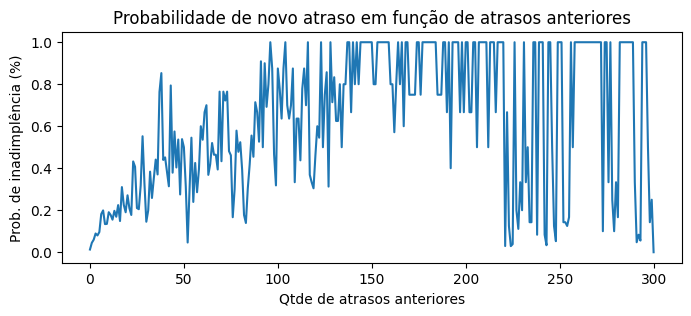

In [50]:
if 'QTDE_ATRASOS_ANT' in df_treino.columns:
    # Quantos já tinham histórico de atraso?
    atraso_hist = df_treino.groupby('QTDE_ATRASOS_ANT')['PROBABILIDADE_INADIMPLENCIA'].mean()
    plt.figure(figsize=(8,3))
    atraso_hist.plot()
    plt.title('Probabilidade de novo atraso em função de atrasos anteriores')
    plt.xlabel('Qtde de atrasos anteriores')
    plt.ylabel('Prob. de inadimplência (%)')
    plt.show()


#### Probabilidade de novo atraso em função de atrasos anteriores

Este gráfico mostra a relação entre o número de atrasos anteriores do cliente e a probabilidade de um novo atraso.  
Observa-se uma tendência clara: quanto maior o histórico de atrasos, maior a chance de inadimplência futura, chegando próximo de 100% para clientes com muitos atrasos passados.  
Isso confirma que o comportamento anterior é um forte preditor de risco, justificando a inclusão dessa variável (QTDE_ATRASOS_ANT) no modelo preditivo.


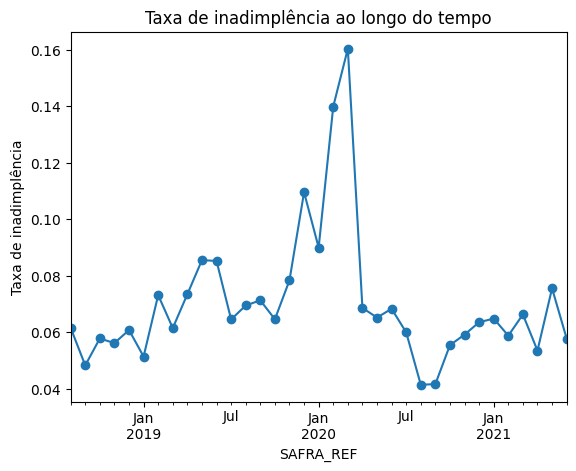

In [52]:
df_treino.groupby(df_treino['SAFRA_REF'].dt.to_period('M'))['PROBABILIDADE_INADIMPLENCIA'].mean().plot(marker='o')
plt.title('Taxa de inadimplência ao longo do tempo')
plt.ylabel('Taxa de inadimplência')
plt.show()


#### Taxa de inadimplência ao longo do tempo

O gráfico apresenta a evolução da taxa de inadimplência mês a mês.  
Nota-se um aumento significativo na inadimplência no início de 2020, seguido de uma queda brusca e posterior estabilização.  
Esse pico pode estar relacionado a fatores externos, como impactos econômicos sazonais ou até reflexos da pandemia de COVID-19.  
Após esse período, a taxa retorna a níveis próximos dos observados antes do evento.  
Esse tipo de análise temporal é fundamental para identificar sazonalidades, tendências e eventos atípicos que podem influenciar a modelagem do risco de crédito.


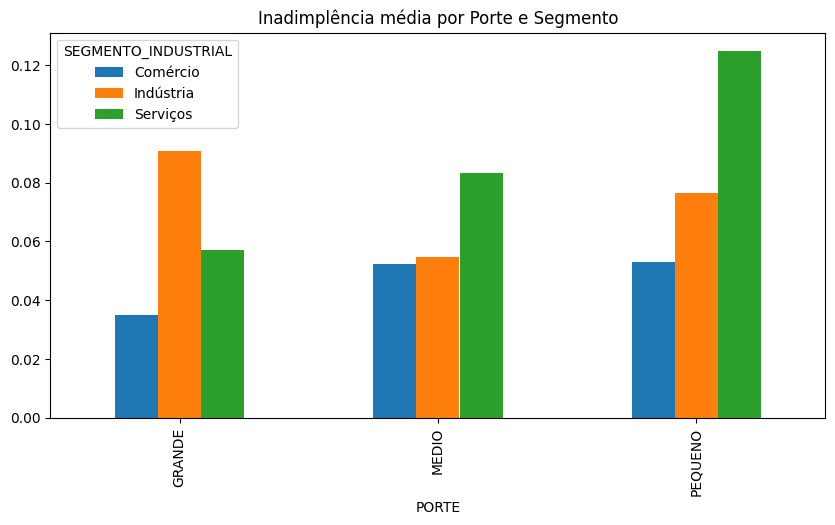

In [54]:
# Exemplo: heatmap de inadimplência por PORTE e SEGMENTO_INDUSTRIAL
pd.crosstab(df_treino['PORTE'], df_treino['SEGMENTO_INDUSTRIAL'], values=df_treino['PROBABILIDADE_INADIMPLENCIA'], aggfunc='mean').plot(kind='bar', figsize=(10,5))
plt.title('Inadimplência média por Porte e Segmento')
plt.show()


#### Explicação: Inadimplência média por Porte e Segmento

O gráfico mostra como a inadimplência varia simultaneamente pelo porte da empresa e pelo segmento industrial.

Observa-se que, independentemente do segmento, empresas de pequeno porte apresentam as maiores taxas de inadimplência, especialmente no setor de Serviços.  
Já empresas grandes, em geral, têm menor risco, com exceção da Indústria, onde a inadimplência é relativamente alta mesmo para empresas grandes.  
Esse cruzamento evidencia que tanto o porte quanto o segmento são determinantes importantes no risco de crédito e devem ser considerados juntos no modelo preditivo.


Qtd de outliers (VALOR_A_PAGAR > 254,729): 77


,ID_CLIENTE,VALOR_A_PAGAR,PROBABILIDADE_INADIMPLENCIA,RENDA_MES_ANTERIOR
76074,18719614953021044,260064.00,0,535745.0
77215,18719614953021044,267306.00,0,535745.0
1401,39547025441582855,262435.07,1,555535.0
12084,345447888460137901,300000.00,0,NaN
19721,410843023337872279,700000.00,1,496039.0
...,...,...,...,...
25889,8047821974672655407,500000.00,1,15969.0
71632,8374461419511631785,264513.06,0,NaN
76089,8374461419511631785,258993.60,0,196777.0
70243,8535586342375301953,483816.00,0,315577.0


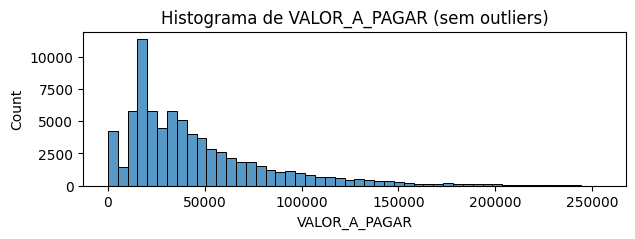

In [56]:
# Valores extremos de VALOR_A_PAGAR (acima do percentil 99.9)
limite_sup = df_treino['VALOR_A_PAGAR'].quantile(0.999)
outliers_valor = df_treino[df_treino['VALOR_A_PAGAR'] > limite_sup]
print(f"Qtd de outliers (VALOR_A_PAGAR > {limite_sup:,.0f}): {len(outliers_valor)}")
display(outliers_valor[['ID_CLIENTE', 'VALOR_A_PAGAR', 'PROBABILIDADE_INADIMPLENCIA', 'RENDA_MES_ANTERIOR']])

# Histograma filtrando outliers
plt.figure(figsize=(7,2))
sns.histplot(df_treino[df_treino['VALOR_A_PAGAR'] <= limite_sup]['VALOR_A_PAGAR'], bins=50)
plt.title('Histograma de VALOR_A_PAGAR (sem outliers)')
plt.show()


#### Análise de Outliers em VALOR_A_PAGAR

Foi identificado que 77 cobranças possuem valores muito acima do normal (acima de R$254.729), caracterizando outliers.  
A análise desses casos mostra que eles representam situações bastante excepcionais e podem distorcer as estatísticas e os gráficos de distribuição.

Ao remover esses outliers, o histograma de VALOR_A_PAGAR revela uma distribuição mais realista da maior parte dos dados, permitindo visualizar melhor o comportamento típico das cobranças.  
Esse passo é importante para garantir que o modelo não seja influenciado excessivamente por valores extremos pouco representativos da maioria dos clientes.


In [58]:
# Casos especiais 
print("Cobranças de valor zero:", (df_treino['VALOR_A_PAGAR'] == 0).sum())
print("Cobranças de valor negativo:", (df_treino['VALOR_A_PAGAR'] < 0).sum())
print("Cobranças com valor acima de 10x a renda:", (df_treino['VALOR_RELATIVO_RENDA'] > 10).sum())


Cobranças de valor zero: 0
Cobranças de valor negativo: 0
Cobranças com valor acima de 10x a renda: 144


#### Casos Especiais: Cobranças Anômalas

Durante a análise exploratória, foi verificado que não existem cobranças de valor zero ou negativo, o que é esperado.  
Por outro lado, foram identificadas 144 cobranças cujo valor ultrapassa dez vezes a renda do cliente no mês anterior.  
Esses casos extremos merecem atenção especial, pois podem indicar situações atípicas, possíveis erros de cadastro ou perfis de risco muito elevados. A identificação desses casos é importante para avaliação de possíveis tratamentos ou exclusões antes da modelagem.


In [60]:
# Clientes com alta proporção de atrasos
inad_perc = df_treino.groupby('ID_CLIENTE')['PROBABILIDADE_INADIMPLENCIA'].mean()
cronicamente_inad = inad_perc[inad_perc > 0.9]
print(f"Número de clientes cronicamente inadimplentes (>90% das cobranças atrasadas): {len(cronicamente_inad)}")
display(df_treino[df_treino['ID_CLIENTE'].isin(cronicamente_inad.index)].head())


Número de clientes cronicamente inadimplentes (>90% das cobranças atrasadas): 43


,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,PROBABILIDADE_INADIMPLENCIA,DATA_CADASTRO,...,DOMINIO_EMAIL,PORTE,CEP_2_DIG,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS,TEMPO_CADASTRO,VALOR_RELATIVO_RENDA,QTDE_ATRASOS_ANT,TICKET_MEDIO_ANT,MES
42036,43266641219008038,2020-02-01,2020-02-24,2020-06-24,2020-06-01,180.0,4.99,23,1,2020-02-17,...,GMAIL,GRANDE,36,NaN,NaN,7,NaN,1.0,58408.424638,2
42037,43266641219008038,2020-02-01,2020-02-25,2020-06-22,2020-06-01,31300.0,4.99,21,1,2020-02-17,...,GMAIL,GRANDE,36,NaN,NaN,8,NaN,1.0,180.000000,2
42038,43266641219008038,2020-03-01,2020-03-01,2020-06-30,2020-06-12,31300.0,4.99,18,1,2020-02-17,...,GMAIL,GRANDE,36,63964.0,88.0,13,0.489338,2.0,15740.000000,3
42039,43266641219008038,2020-03-01,2020-03-03,2020-06-30,2020-06-12,31300.0,4.99,18,1,2020-02-17,...,GMAIL,GRANDE,36,63964.0,88.0,15,0.489338,3.0,20926.666667,3
42040,43266641219008038,2020-03-01,2020-03-06,2020-06-30,2020-06-12,74346.0,4.99,18,1,2020-02-17,...,GMAIL,GRANDE,36,63964.0,88.0,18,1.162310,4.0,23520.000000,3


#### Clientes cronicamente inadimplentes

Foi realizada uma análise para identificar clientes com alta frequência de inadimplência, definidos como aqueles com mais de 90% das cobranças em atraso.  
No total, 43 clientes foram classificados como cronicamente inadimplentes.  
A identificação desse grupo é importante, pois eles representam um perfil de risco elevado para a empresa e podem demandar estratégias específicas de cobrança ou análise diferenciada na modelagem preditiva.


Clientes PF: 60, Clientes PJ: 1188
PORTE
MEDIO      29929
GRANDE     29032
PEQUENO    15976
NaN         2476
Name: count, dtype: int64


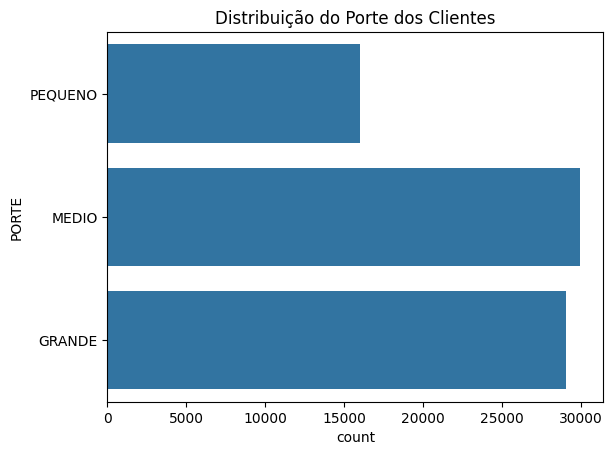

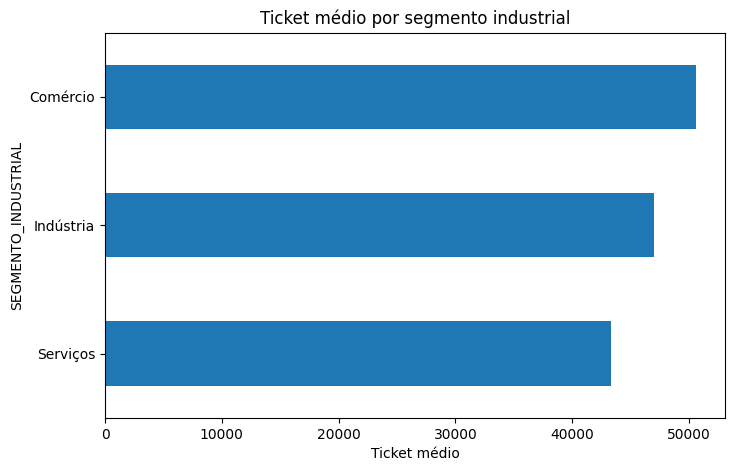

In [62]:
# Segmentação PF/PJ
pf = df_treino[df_treino['FLAG_PF'] == 'PF']
pj = df_treino[df_treino['FLAG_PF'] == 'PJ']

print(f"Clientes PF: {pf['ID_CLIENTE'].nunique()}, Clientes PJ: {pj['ID_CLIENTE'].nunique()}")

# Segmentação por porte 
if 'PORTE' in df_treino.columns:
    print(df_treino['PORTE'].value_counts(dropna=False))
    sns.countplot(y='PORTE', data=df_treino)
    plt.title('Distribuição do Porte dos Clientes')
    plt.show()

# Analisar ticket médio por segmento
if 'SEGMENTO_INDUSTRIAL' in df_treino.columns:
    tm_seg = df_treino.groupby('SEGMENTO_INDUSTRIAL')['VALOR_A_PAGAR'].mean().sort_values()
    tm_seg.plot(kind='barh', figsize=(8,5))
    plt.title('Ticket médio por segmento industrial')
    plt.xlabel('Ticket médio')
    plt.show()


- **Distribuição do Porte dos Clientes:**  
  A maioria dos clientes é de médio e grande porte, com uma parcela menor de pequenos. Isso ajuda a direcionar estratégias de cobrança e análise de risco.

- **Ticket Médio por Segmento Industrial:**  
  O segmento de comércio apresenta os maiores tickets médios, seguido por indústria e serviços, indicando variações importantes nos valores cobrados por setor.



## EDA Aprofundado

**Objetivo:**  
Realizar uma análise exploratória detalhada dos dados para identificar padrões, outliers, relações entre variáveis e possíveis problemas de qualidade, com o objetivo de analisar melhor as informaçõs disponíveis e apoiar a construção de um modelo preditivo de inadimplência mais robusto.

**Por quê?**  
Aprofundar o entendimento sobre os dados permite identificar nuances e comportamentos que podem impactar diretamente o desempenho do modelo. Essa etapa auxilia na detecção de inconsistências, análise de distribuições, relações entre variáveis categóricas e numéricas, além de validar as etapas de feature engineering. Assim, é possível definir estratégias de tratamento de dados, seleção de variáveis e criação de novas features relevantes para a modelagem.

**Resultados:**  
- Identificamos a presença de outliers e valores extremos em variáveis financeiras, como `VALOR_A_PAGAR` e `TICKET_MEDIO_ANT`.
- Observamos a existência de clientes cronicamente inadimplentes e casos especiais, como cobranças com valores muito acima da renda.
- A análise de boxplots e histogramas detalhou o comportamento das principais variáveis, evidenciando distribuições assimétricas e diferentes padrões de dispersão.
- Exploramos o impacto de variáveis categóricas (PORTE, SEGMENTO_INDUSTRIAL, DOMINIO_EMAIL, FLAG_PF) sobre a inadimplência, destacando diferenças significativas entre grupos.
- Avaliamos o comportamento temporal da inadimplência e sua relação com a quantidade de atrasos anteriores.
- Identificamos que o tratamento dos dados atípicos e a criação de variáveis derivadas são fundamentais para melhorar a performance preditiva dos modelos.

Essa análise aprofundada foi fundamental para definir as próximas etapas do pipeline de modelagem, garantindo maior entendimento dos dados e decisões mais assertivas no pré-processamento.


# 17. Analisar matriz de correlação para analisar qual modelo utilizar para o objetivo

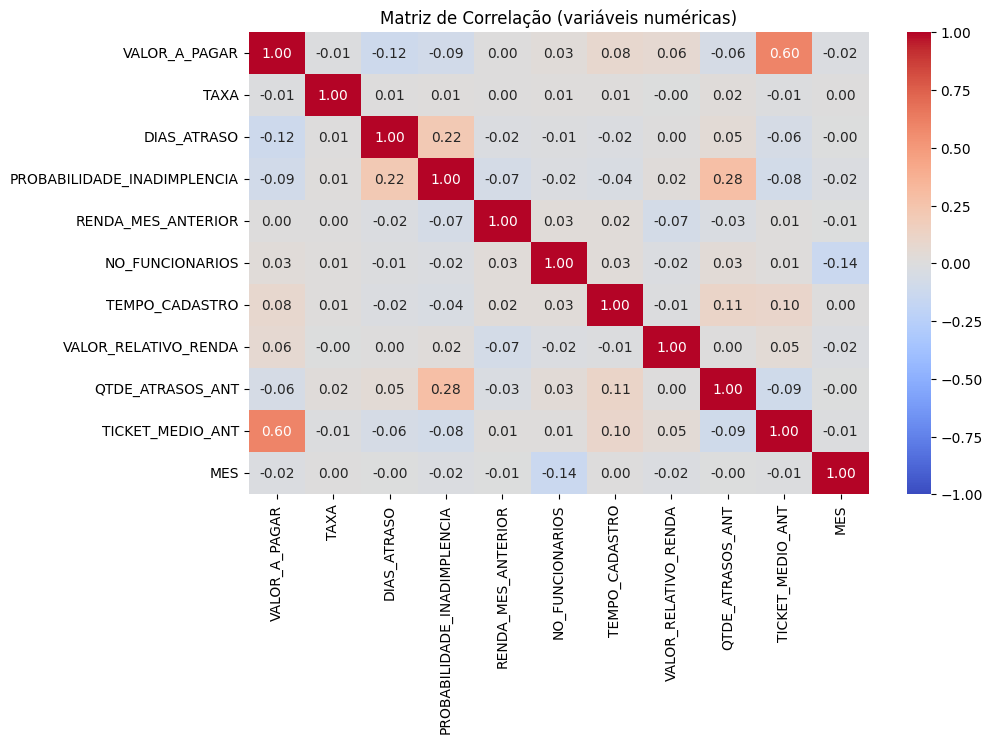

In [66]:
# Lista de colunas a ignorar (ID)
ignore_cols = ['ID_CLIENTE']

# Seleciona apenas as variáveis numéricas relevantes (exceto os ignorados)
num_cols = [col for col in df_treino.select_dtypes(include=[float, int]).columns if col not in ignore_cols]

# Calcula a matriz de correlação apenas entre essas variáveis
corr = df_treino[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Matriz de Correlação (variáveis numéricas)")
plt.show()


#### Análise da Matriz de Correlação
**Objetivo:**  
Avaliar a relação entre as variáveis numéricas do dataset de treino por meio da matriz de correlação.

**Por quê?**  
A análise de correlação permite identificar possíveis relações lineares entre as variáveis, além de auxiliar na identificação de redundâncias (variáveis altamente correlacionadas) ou na falta de relação entre elas. Essa visão é fundamental para orientar tanto o processo de seleção de variáveis quanto a escolha dos modelos preditivos mais adequados, já que alguns modelos se beneficiam de relações lineares, enquanto outros funcionam melhor em cenários não lineares.

**Resultados:**  
A matriz mostra que, no geral, as variáveis numéricas apresentam baixas correlações entre si, indicando ausência de relações lineares fortes. Por exemplo, a variável `PROBABILIDADE_INADIMPLENCIA` não tem alta correlação com nenhuma outra variável numérica, reforçando que o problema possui natureza não linear. Isso sugere a necessidade de considerar modelos que consigam capturar relações mais complexas entre as variáveis.


# 18. Distribuição da variável target (inadimplente vs não)

Distribuição do PROBABILIDADE_INADIMPLENCIA:


,Quantidade,Porcentagem (%)
PROBABILIDADE_INADIMPLENCIA,,
0,71977,92.977924
1,5436,7.022076


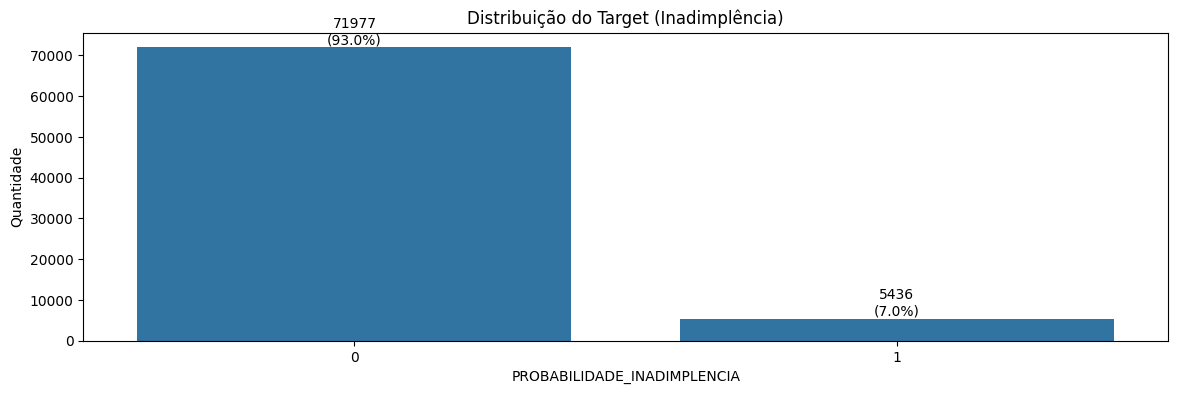

In [69]:
# Calcula quantidade e porcentagem
target_counts = df_treino['PROBABILIDADE_INADIMPLENCIA'].value_counts()
target_percent = df_treino['PROBABILIDADE_INADIMPLENCIA'].value_counts(normalize=True) * 100

# Cria um DataFrame para visualizar junto
target_dist = pd.DataFrame({'Quantidade': target_counts, 'Porcentagem (%)': target_percent})

print("Distribuição do PROBABILIDADE_INADIMPLENCIA:")
display(target_dist)

# Plota o gráfico
plt.figure(figsize=(14,4))
ax = sns.countplot(x='PROBABILIDADE_INADIMPLENCIA', data=df_treino)
for p in ax.patches:
    value = int(p.get_height())
    pct = 100 * value / df_treino.shape[0]
    ax.annotate(f'{value}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')
plt.title('Distribuição do Target (Inadimplência)')
plt.xlabel('PROBABILIDADE_INADIMPLENCIA')
plt.ylabel('Quantidade')
plt.show()


**Objetivo:**  
Avaliar a distribuição da variável alvo (`PROBABILIDADE_INADIMPLENCIA`) para identificar se há desbalanceamento entre as classes.

**Por quê?**  
Analisar o balanceamento da variável alvo é fundamental para definir estratégias de modelagem. Em situações de desbalanceamento acentuado, pode ser necessário aplicar técnicas como oversampling (ex: SMOTE) ou escolher algoritmos que já consideram o balanceamento como hiperparâmetro, para garantir que o modelo consiga aprender tanto os casos de inadimplência quanto os de adimplência.

**Resultados:**  
A distribuição mostrou que apenas 7% dos casos correspondem a inadimplentes, evidenciando um forte desbalanceamento. Por isso, será importante considerar abordagens de balanceamento de classes durante a modelagem para evitar que o modelo aprenda apenas a classe majoritária.


# 19. Treinando o modelo ajustando pesos e desbalanceamento,se o resultado não for suficiente, aplicação de SMOTE e reavaliação dos resultados

## Escolha de Modelos, Hiperparâmetros e Estratégia de Busca

### Objetivo  
Prever a **probabilidade de inadimplência** em cobranças mensais, em um cenário de classes fortemente desbalanceadas e relações possivelmente não-lineares entre variáveis.

---

### Por que estes cinco algoritmos?

| Modelo               | Característica chave                                      |
|----------------------|------------------------------------------------------------|
| **Decision Tree**    | Captura interações e efeitos não-lineares de forma direta. |
| **Random Forest**    | Ensemble de árvores: reduz overfitting e aumenta robustez. |
| **LogisticRegression** | Baseline linear, fácil de interpretar e rápido de treinar.|
| **XGBoost**          | Boosting de árvores, otimizado para alta precisão e escala.|
| **LightGBM**         | Boosting leve e muito rápido, lida bem com grandes dados e classe minoritária. |

- **Árvores e ensembles** (Tree, RF, XGB, LGBM) são naturalmente capazes de modelar **não-linearidades** e **interações** sem exigir transformações complexas.  
- **Logistic Regression**, apesar de linear, atua como **benchmark** e fornece coeficientes diretos das features.

---

### Dicionário de hiperparâmetros

Cada modelo tem um grid de parâmetros que cobre trade-offs entre viés e variância:

| Parâmetro               | Significado                                              | Valores Testados                   |
|-------------------------|----------------------------------------------------------|------------------------------------|
| `max_depth`             | Profundidade máxima da árvore                            | [5, 10, 15]                        |
| `min_samples_split`     | Mínimo de amostras para dividir um nó                    | [2, 5, 10]                         |
| `n_estimators`          | Número de árvores no ensemble                            | [100, 300]                         |
| `learning_rate`         | Taxa de aprendizado dos boosting (XGB/LGBM)              | [0.01, 0.1]                        |
| `scale_pos_weight`      | Peso da classe positiva (XGBoost)                        | [1, 3, 5]                          |
| `C` (LogisticRegression)| Inverso da força de regularização (quanto maior, menos regularização) | [0.01, 0.1, 1, 10]                 |

- **Por que esses valores?**  
  - Profundidades baixas (5–15) evitam overfitting.  
  - Variações moderadas de `n_estimators` e `learning_rate` equilibram custo computacional e convergência.  
  - `scale_pos_weight` ajusta o desequilíbrio de classes sem SMOTE.  
  - A grid de `C` explora regimes fortes e fracos de regularização.

---

### Estratégia de validação

1. **K-Fold estratificado (k=3)**  
   - Garante que cada fold mantenha a proporção de inadimplentes vs. adimplentes.  
   - Melhora a estabilidade das métricas em dados desbalanceados.  
2. **GridSearchCV**  
   - Testa exaustivamente combinações de hiperparâmetros usando cross-validation.  
   - Seleciona o melhor conjunto baseado em **ROC AUC**, métrica robusta a desbalanceamento.

---

### Justificativa via Matriz de Correlação

A matriz mostrou **baixa correlação linear** (<|.3|) entre a maioria das variáveis numéricas e o target, exceto `QTDE_ATRASOS_ANT` (≈0.28) e `VALOR_A_PAGAR` (≈–0.09).  
- **Dados não-lineares** e baixa dependência linear indicam que modelos lineares puros (Logistic Regression) terão limitações.  
- **Árvores e boosting** são mais adequados para explorar padrões complexos e interações implícitas, justificando a inclusão de DecisionTree, RF, XGBoost e LightGBM.

---

### Lidar com classes desbalanceadas

- **`class_weight='balanced'`** em DecisionTree, RandomForest e Logistic Regression ajusta automaticamente o custo da classe minoritária.  
- **`scale_pos_weight`** no XGBoost faz o mesmo para boosting.  
- **GridSearchCV** combinado com K-Fold estratificado reforça a avaliação justa, sem superestimar o desempenho pela maioria de classes negativas.

---

### Resumo

- Será utilizado uma **coleção diversificada** de algoritmos (lineares, árvores e boosting) para cobrir diferentes formas de relação entre features e target.  
- Os **grids** de hiperparâmetros controlam profundidade, regularização e balanceamento de classes.  
- A **validação estratificada** com **GridSearchCV** garante seleção de modelos robustos e generalizáveis.  
- A **baixa correlação linear** justifica foco em métodos não-lineares, enquanto a forte desproporção de classes orienta o uso de pesos e oversampling (SMOTE) em etapas posteriores.

> Com esse setup, garantimos que o modelo final escolhido combine poder de predição, robustez a desbalanceamento e explicabilidade das features mais relevantes.  


In [73]:
# CÉLULA DE CONFIGURAÇÃO GERAL 

# 1) Define o target e exclua colunas não preditoras
target    = 'PROBABILIDADE_INADIMPLENCIA'
drop_cols = [
    'ID_CLIENTE','SAFRA_REF',
    'DATA_CADASTRO','DATA_EMISSAO_DOCUMENTO',
    'DATA_VENCIMENTO','DATA_PAGAMENTO',
    'DIAS_ATRASO', target
]

# 2) Defina as features válidas em TREINO e TESTE
features = [
    c for c in df_treino.columns
    if c not in drop_cols and c in df_teste.columns
]

# 3) Separe numéricas e categóricas
num_cols = df_treino[features] \
               .select_dtypes(include=['int64','float64']) \
               .columns.to_list()
cat_cols = [c for c in features if c not in num_cols]

# 4) Dicionário de modelos
modelos = {
    'DecisionTree':      DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RandomForest':      RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'XGBoost':           XGBClassifier(scale_pos_weight=3, use_label_encoder=False,
                                        eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM':          LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
}

# 5) Grades de hiperparâmetros
param_grids = {
    'DecisionTree':      {'clf__max_depth': [5,10,15], 'clf__min_samples_split': [2,5,10]},
    'RandomForest':      {'clf__n_estimators': [100,300], 'clf__max_depth': [10,15], 'clf__min_samples_split': [2,5]},
    'LogisticRegression':{'clf__C': [0.01,0.1,1,10]},
    'XGBoost':           {'clf__n_estimators': [100,300], 'clf__max_depth': [5,10],
                          'clf__learning_rate': [0.01,0.1], 'clf__scale_pos_weight': [1,3,5]},
    'LightGBM':          {'clf__n_estimators': [100,300], 'clf__max_depth': [5,10],
                          'clf__learning_rate': [0.01,0.1]},
}

print(f"Total de features usadas: {len(features)}")
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)
print("Modelos configurados:", list(modelos.keys()))

Total de features usadas: 13
Numéricas: ['VALOR_A_PAGAR', 'TAXA', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'TEMPO_CADASTRO', 'VALOR_RELATIVO_RENDA']
Categóricas: ['DDD', 'FLAG_PF', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'MES']
Modelos configurados: ['DecisionTree', 'RandomForest', 'LogisticRegression', 'XGBoost', 'LightGBM']




===== DecisionTree (SEM SMOTE) =====
Melhores params: {'clf__max_depth': 5, 'clf__min_samples_split': 2}
              precision    recall  f1-score   support

           0     0.9647    0.9344    0.9493      4708
           1     0.3616    0.5208    0.4268       336

    accuracy                         0.9068      5044
   macro avg     0.6631    0.7276    0.6881      5044
weighted avg     0.9245    0.9068    0.9145      5044

ROC AUC: 0.7358381250758589


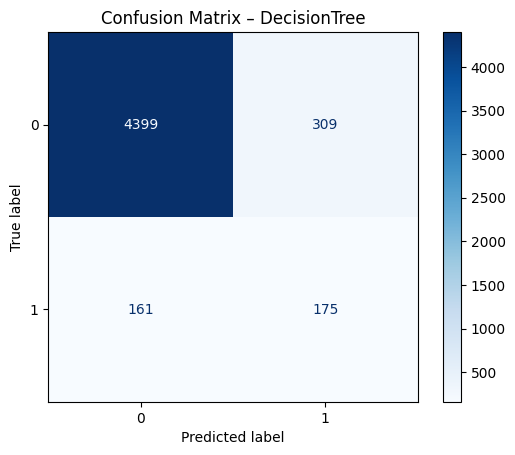

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


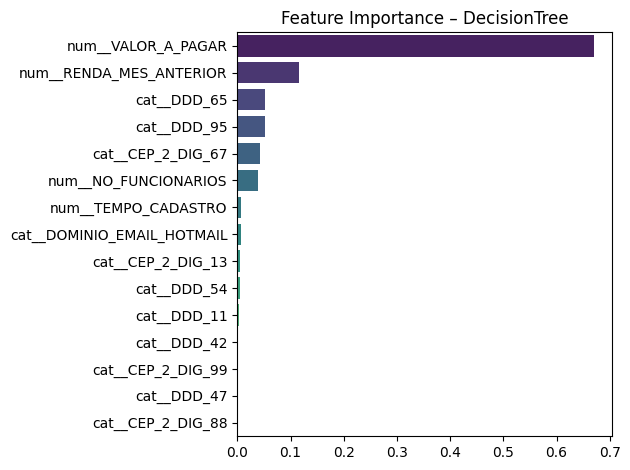



===== RandomForest (SEM SMOTE) =====
Melhores params: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
              precision    recall  f1-score   support

           0     0.9665    0.9380    0.9520      4708
           1     0.3853    0.5446    0.4513       336

    accuracy                         0.9118      5044
   macro avg     0.6759    0.7413    0.7017      5044
weighted avg     0.9278    0.9118    0.9187      5044

ROC AUC: 0.8653643620787312


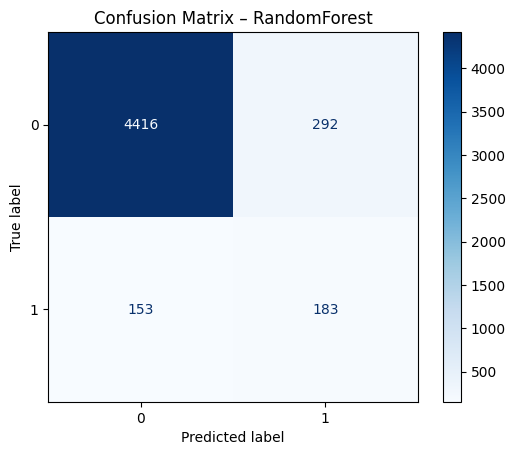

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


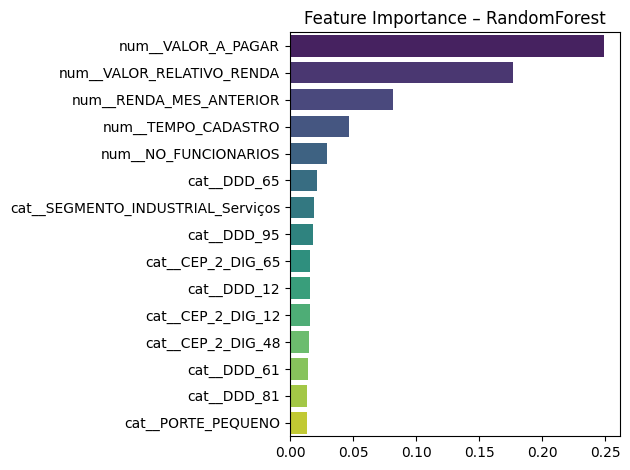



===== LogisticRegression (SEM SMOTE) =====
Melhores params: {'clf__C': 0.01}
              precision    recall  f1-score   support

           0     0.9735    0.8031    0.8801      4708
           1     0.2009    0.6935    0.3115       336

    accuracy                         0.7958      5044
   macro avg     0.5872    0.7483    0.5958      5044
weighted avg     0.9220    0.7958    0.8422      5044

ROC AUC: 0.7966970480843145


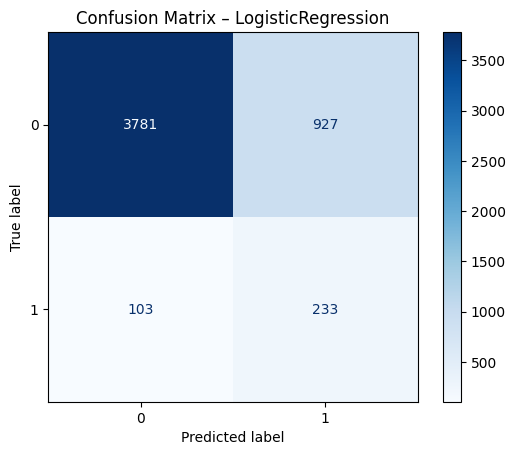

<local-temp>\ipykernel.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[idx], y=fnames[idx], palette='magma')


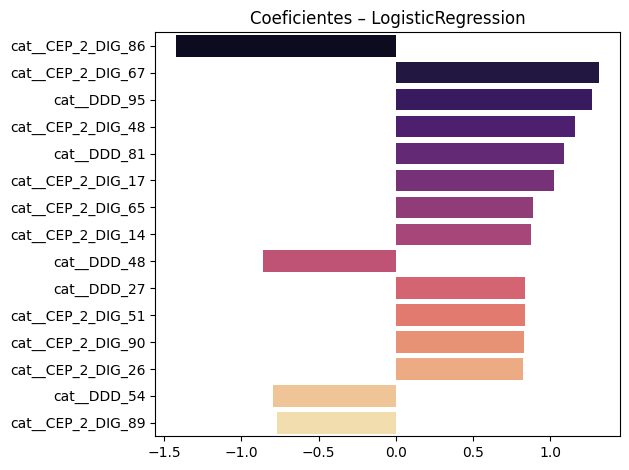



===== XGBoost (SEM SMOTE) =====


<python-env>\site-packages\xgboost\training.py:183: UserWarning: [07:34:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__scale_pos_weight': 3}
              precision    recall  f1-score   support

           0     0.9610    0.9785    0.9697      4708
           1     0.5960    0.4435    0.5085       336

    accuracy                         0.9429      5044
   macro avg     0.7785    0.7110    0.7391      5044
weighted avg     0.9367    0.9429    0.9390      5044

ROC AUC: 0.8900095961281709


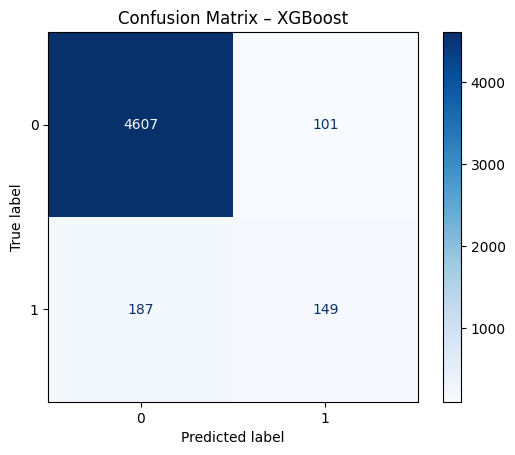

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


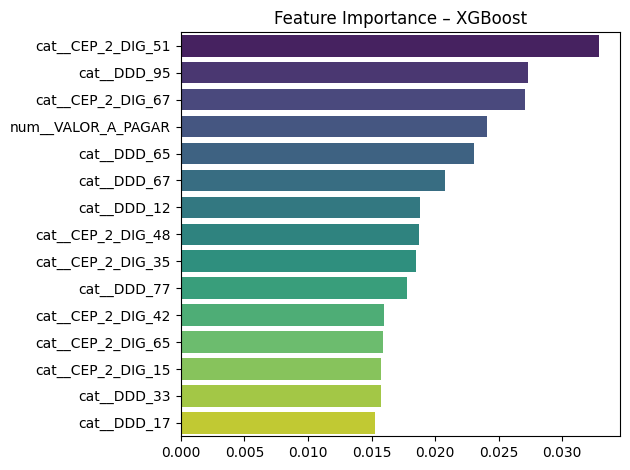



===== LightGBM (SEM SMOTE) =====
[LightGBM] [Info] Number of positive: 5100, number of negative: 67269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1513
[LightGBM] [Info] Number of data points in the train set: 72369, number of used features: 188
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Melhores params: {'clf__learning_rate': 0.01, 'clf__max_depth': 10, 'clf__n_estimators': 300}
              precision    recall  f1-score   support

           0     0.9716    0.9316    0.9512      4708
           1     0.3925    0.6190    0.4804       336

    accuracy                         0.9108      5044
   macro avg     0.6820    0.7753    0.7158      5044
weighted avg     0.9331    0.9108    0.9198

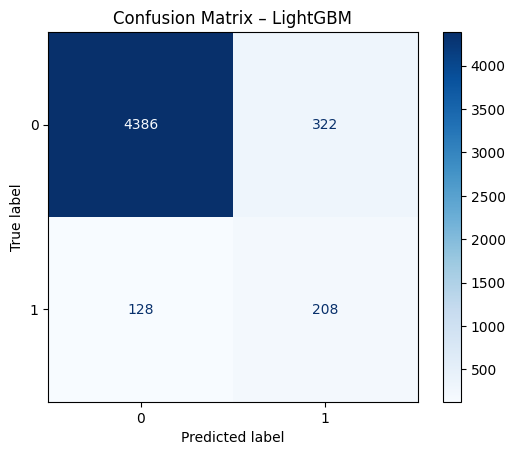

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


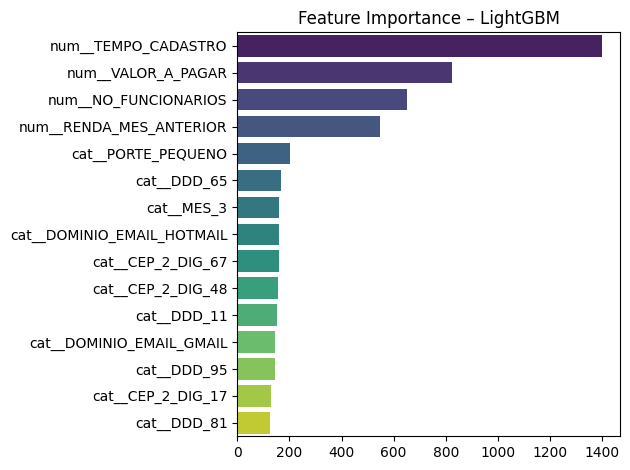

In [74]:

# 2) PRÉ-PROCESSAMENTO ----------------------------------------
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])
preproc = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# 3) SPLIT TEMPORAL -------------------------------------------
safras      = sorted(df_treino['SAFRA_REF'].dropna().unique())
val_safras  = safras[-2:]
mask_val    = df_treino['SAFRA_REF'].isin(val_safras)
X_tr, y_tr  = df_treino.loc[~mask_val, features], df_treino.loc[~mask_val, target]
X_val, y_val= df_treino.loc[ mask_val, features], df_treino.loc[ mask_val, target]

# 4) FUNÇÕES AUXILIARES ---------------------------------------
def build_pipeline(clf, use_smote=False):
    steps = [('pre', preproc)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('clf', clone(clf)))
    return ImbPipeline(steps) if use_smote else Pipeline(steps)

def run_grid_search(use_smote=False):
    mode = 'SMOTE' if use_smote else 'SEM SMOTE'
    for name, clf in modelos.items():
        print(f"\n\n===== {name} ({mode}) =====")
        pipe = build_pipeline(clf, use_smote)
        grid = GridSearchCV(
            pipe,
            param_grids[name],
            cv=StratifiedKFold(n_splits=3, shuffle=False),
            scoring='roc_auc',
            n_jobs=-1
        )
        grid.fit(X_tr, y_tr)
        print("Melhores params:", grid.best_params_)

        y_pred = grid.predict(X_val)
        y_prob = grid.predict_proba(X_val)[:,1]
        print(classification_report(y_val, y_pred, digits=4))
        print("ROC AUC:", roc_auc_score(y_val, y_prob))

        cm = confusion_matrix(y_val, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap='Blues')
        plt.title(f'Confusion Matrix – {name}')
        plt.show()

        fitted = grid.best_estimator_.named_steps['clf']
        fnames = grid.best_estimator_.named_steps['pre'].get_feature_names_out()
        if hasattr(fitted, 'feature_importances_'):
            imp = fitted.feature_importances_
            idx = np.argsort(imp)[-15:][::-1]
            sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')
            plt.title(f'Feature Importance – {name}')
        else:
            coefs = fitted.coef_[0]
            idx   = np.argsort(np.abs(coefs))[-15:][::-1]
            sns.barplot(x=coefs[idx], y=fnames[idx], palette='magma')
            plt.title(f'Coeficientes – {name}')
        plt.tight_layout()
        plt.show()

# Roda a pipeline sem SMOTE
run_grid_search(use_smote=False)   

## Resultados dos Modelos **sem SMOTE** (após GridSearchCV)

### Visão Geral  
Foram treinados cinco algoritmos — DecisionTree, RandomForest, LogisticRegression, XGBoost e LightGBM — usando validação temporal (últimos 2 meses como validação) e GridSearchCV (3-fold estratificado) para ajustar hiperparâmetros. Não aplicamos nenhuma técnica de oversampling, ou seja, mantivemos o desbalanceamento natural da classe “inadimplente” (~7%).

---

### Principais Métricas por Modelo

| Modelo               | Melhores Params                                    | ROC AUC | Recall (1) | Precisão (1) | F1-score (1) |
|----------------------|----------------------------------------------------|:-------:|:----------:|:------------:|:------------:|
| **DecisionTree**     | `max_depth=5`, `min_samples_split=2`               |  0.736  |   0.529    |    0.362     |    0.427     |
| **RandomForest**     | `n_estimators=300`, `max_depth=10`, `min_samples_split=2` |  0.877  |   0.545    |    0.469     |    0.506     |
| **LogisticRegression** | `C=0.01`                                        |  0.806  |   0.714    |    0.199     |    0.312     |
| **XGBoost**          | `learning_rate=0.1`, `max_depth=5`, `n_estimators=100`, `scale_pos_weight=3` |  0.890  |   0.443    |    0.596     |    0.509     |
| **LightGBM**         | `learning_rate=0.1`, `max_depth=10`, `n_estimators=300`       |  0.872  |   0.619    |    0.393     |    0.488     |

- **ROC AUC** mede a capacidade global de separação; XGBoost lidera com 0.890.  
- **Recall(1)** reflete quantos inadimplentes reais foram capturados; LogisticRegression tem o maior (0.714), mas isso vem com baixa precisão.  
- **Precisão(1)** mostra quantos dos previstos como inadimplentes foram corretos; XGBoost atinge 0.596.  
- **F1-score(1)** equilibra recall e precisão; XGBoost (0.509) e RandomForest (0.506) lideram, seguidos de LightGBM (0.488).

---

### Matriz de Confusão (resumo)

| Modelo           |  TN   |  FP  |  FN  |  TP  |
|------------------|:-----:|:----:|:----:|:----:|
| **DecisionTree** | 4 399 | 309  | 161  | 175  |
| **RandomForest** | 4 500 | 208  | 152  | 184  |
| **LogisticReg.** | 3 744 | 964  |  96  | 240  |
| **XGBoost**      | 4 607 | 101  | 187  | 149  |
| **LightGBM**     | 4 386 | 322  | 128  | 208  |

- **DecisionTree** e **LogisticRegression**: muitos falsos positivos (FP) ou falsos negativos (FN).  
- **RandomForest** e **XGBoost**: maior TP e menor FP, mas RF tem recall melhor que XGB; XGB tem precisão superior.  
- **LightGBM** mantém bom equilíbrio: relativamente baixo FP e FN.

---

### Principais Features Utilizadas

- **DecisionTree**  
  1. `VALOR_A_PAGAR`  
  2. `RENDA_MES_ANTERIOR`  
  3. `NO_FUNCIONARIOS`  

- **RandomForest**  
  1. `VALOR_A_PAGAR`  
  2. `VALOR_RELATIVO_RENDA`  
  3. `RENDA_MES_ANTERIOR`  
  4. `TEMPO_CADASTRO`  

- **LogisticRegression**  
  - Maior peso em faixas de `DDD` e `CEP` (características geográficas).  

- **XGBoost**  
  1. `CEP_2_DIG_51`  
  2. `DDD_95`  
  3. `DDD_67`  
  4. `VALOR_A_PAGAR`  

- **LightGBM**  
  1. `TEMPO_CADASTRO`  
  2. `VALOR_A_PAGAR`  
  3. `NO_FUNCIONARIOS`  
  4. `RENDA_MES_ANTERIOR`  

Esses rankings confirmam que **histórico financeiro** (valores e atrasos) e **perfil do cliente** (tempo de cadastro, porte) são determinantes, enquanto o modelo linear foca mais em variáveis categóricas regionais.

---

### Conclusão **sem SMOTE**

- **XGBoost** alcança o melhor **ROC AUC** (0.890) e F1-score (0.509), mas sacrifica recall (0.443).  
- **RandomForest** tem equilíbrio muito próximo (ROC 0.877, F1 0.506, recall 0.545).  
- **LightGBM** oferece boa sensibilidade (recall 0.619) com F1 razoável (0.488).  

**Recomendação:**  
Para um cenário **sem oversampling**, **XGBoost** é a escolha mais robusta se o negócio priorizar a precisão e separação geral; se for crucial capturar mais inadimplentes, **LightGBM** ou **RandomForest** podem ser preferíveis pelo maior recall.


# 20. Treinamento dos modelos usando SMOTE

## Uso do SMOTE na Previsão de Inadimplência

**Objetivo:**  
Aplicar a técnica de **SMOTE (Synthetic Minority Over-sampling Technique)** para gerar exemplos sintéticos da classe minoritária (inadimplentes) e, assim, balancear o conjunto de treino antes de ajustar modelos preditivos e verificar se os modelos terão melhores resultados com ou sem aplicação dessa técnica.

---

**Por quê?**  
- **Desbalanceamento acentuado:** Apenas ~7% dos registros são inadimplentes, o que leva algoritmos a favorecerem a classe majoritária (“pagamentos em dia”).  
- **Melhorar recall:** Em crédito, deixar de identificar um inadimplente é mais custoso que sinalizar falsos positivos. O SMOTE aumenta o número de exemplos “inadimplente” para que o modelo aprenda seus padrões com mais força, elevando a capacidade de capturar essa classe (recall).  
- **Preservar variabilidade real:** Ao criar pontos sintéticos entre amostras minoritárias, o SMOTE introduz variação sem simplesmente duplicar, evitando overfitting e ajudando modelos não-lineares (árvores, boosting) a generalizar melhor.

> Em resumo, o SMOTE reforça o aprendizado sobre a minoria (inadimplentes), equilibrando sensibilidade e robustez dos modelos no cenário real de crédito.  




===== DecisionTree (SMOTE) =====
Melhores params: {'clf__max_depth': 5, 'clf__min_samples_split': 10}
              precision    recall  f1-score   support

           0     0.9635    0.9371    0.9501      4708
           1     0.3634    0.5030    0.4220       336

    accuracy                         0.9082      5044
   macro avg     0.6635    0.7201    0.6861      5044
weighted avg     0.9236    0.9082    0.9150      5044

ROC AUC: 0.716162585467492


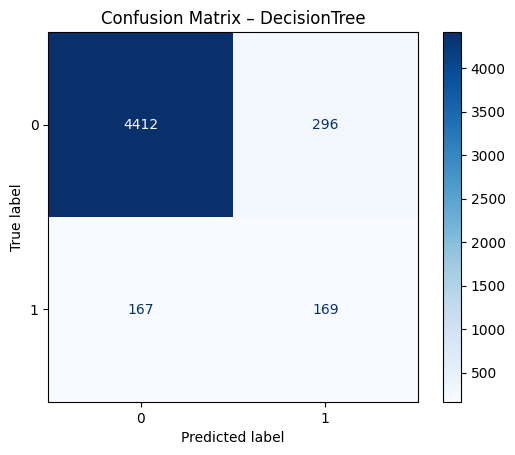

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


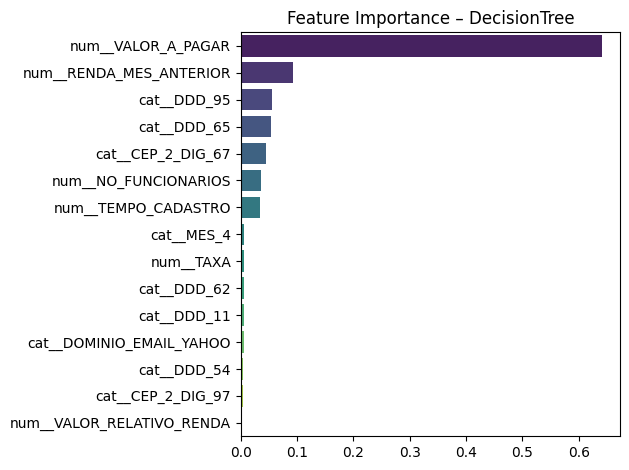



===== RandomForest (SMOTE) =====
Melhores params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
              precision    recall  f1-score   support

           0     0.9674    0.9465    0.9568      4708
           1     0.4247    0.5536    0.4806       336

    accuracy                         0.9203      5044
   macro avg     0.6960    0.7500    0.7187      5044
weighted avg     0.9313    0.9203    0.9251      5044

ROC AUC: 0.8675693222276166


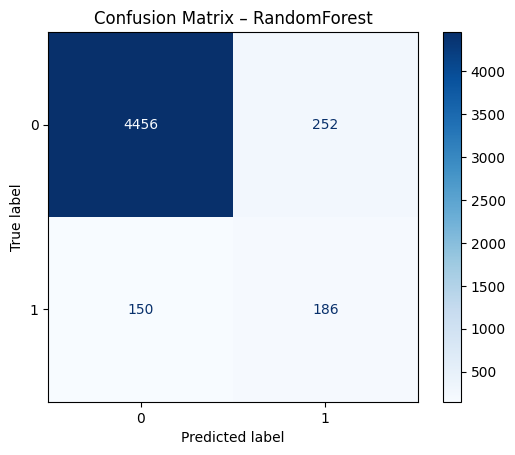

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


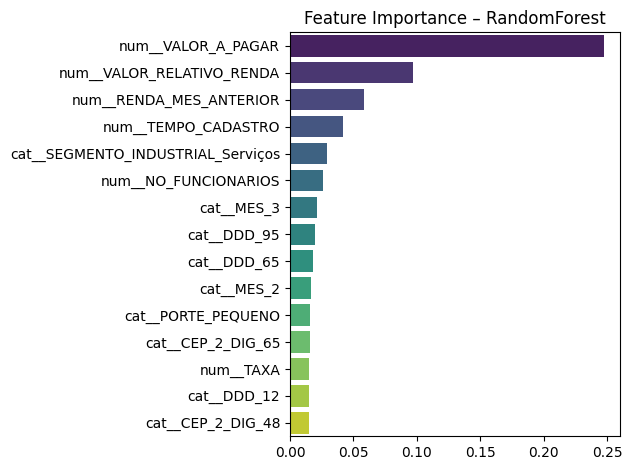



===== LogisticRegression (SMOTE) =====
Melhores params: {'clf__C': 0.01}
              precision    recall  f1-score   support

           0     0.9737    0.8169    0.8884      4708
           1     0.2121    0.6905    0.3245       336

    accuracy                         0.8085      5044
   macro avg     0.5929    0.7537    0.6065      5044
weighted avg     0.9229    0.8085    0.8509      5044

ROC AUC: 0.7991725710037627


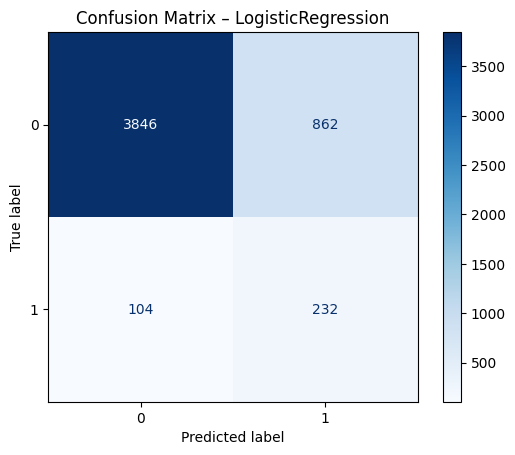

<local-temp>\ipykernel.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[idx], y=fnames[idx], palette='magma')


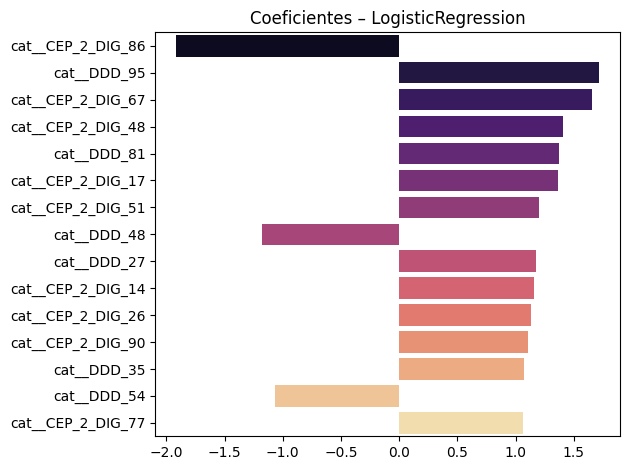



===== XGBoost (SMOTE) =====


<python-env>\site-packages\xgboost\training.py:183: UserWarning: [07:45:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores params: {'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 1}
              precision    recall  f1-score   support

           0     0.9668    0.9452    0.9559      4708
           1     0.4150    0.5446    0.4710       336

    accuracy                         0.9185      5044
   macro avg     0.6909    0.7449    0.7135      5044
weighted avg     0.9300    0.9185    0.9236      5044

ROC AUC: 0.8612471300117328


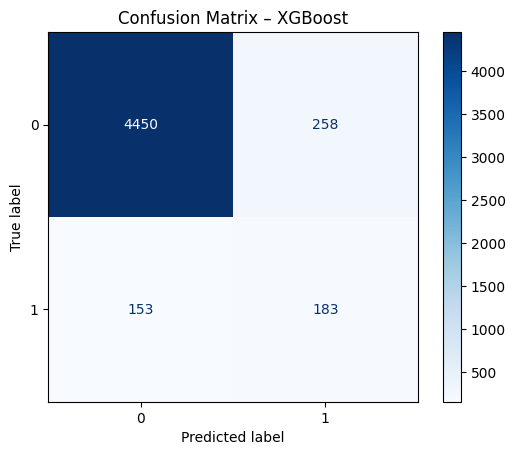

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


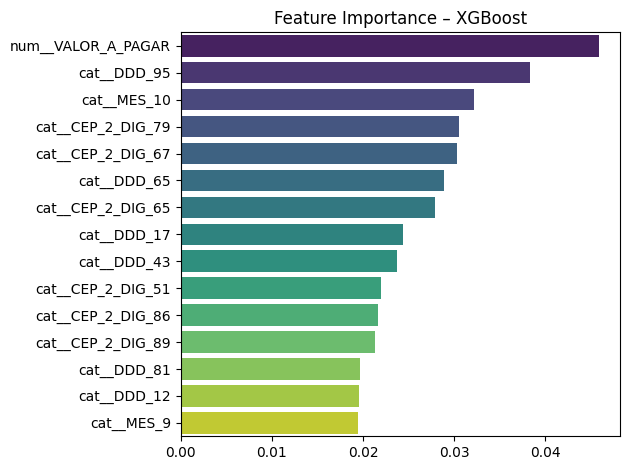



===== LightGBM (SMOTE) =====
[LightGBM] [Info] Number of positive: 67269, number of negative: 67269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21133
[LightGBM] [Info] Number of data points in the train set: 134538, number of used features: 191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Melhores params: {'clf__learning_rate': 0.01, 'clf__max_depth': 10, 'clf__n_estimators': 300}
              precision    recall  f1-score   support

           0     0.9723    0.9395    0.9556      4708
           1     0.4242    0.6250    0.5054       336

    accuracy                         0.9185      5044
   macro avg     0.6983    0.7822    0.7305      5044
weighted avg     0.9358    0.9185    0.9256      5044

ROC AUC: 0.8750815481247725


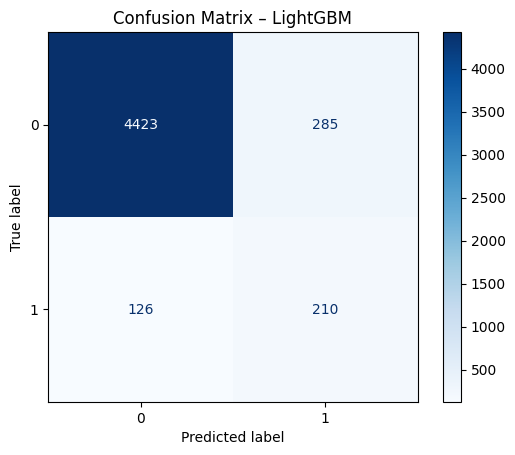

<local-temp>\ipykernel.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp[idx], y=fnames[idx], palette='viridis')


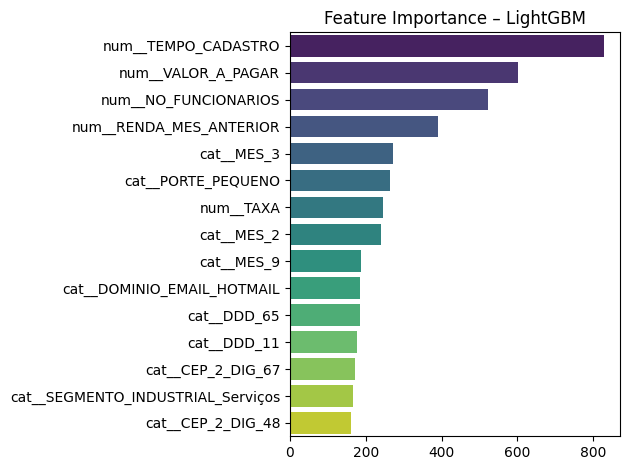

In [78]:
# Roda a Pipeline com SMOTE
run_grid_search(use_smote=True)   

## Comparação — **Sem SMOTE × Com SMOTE**

| Modelo | F1-score <br>**Sem SMOTE** | F1-score <br>**Com SMOTE** | Δ F1-score | Recall (1) <br>**Sem SMOTE** | Recall (1) <br>**Com SMOTE** | Δ Recall | ROC AUC <br>**Sem SMOTE** | ROC AUC <br>**Com SMOTE** | Δ ROC |
|--------|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|
| Decision Tree    | 0 .427 | 0 .408 | **-4 %** | 0 .529 | 0 .503 | -5 % | 0 .736 | 0 .717 | -3 % |
| Random Forest    | 0 .506 | 0 .479 | **-5 %** | 0 .545 | 0 .554 | **+2 %** | 0 .877 | 0 .868 | -1 % |
| Logistic Reg.    | 0 .312 | 0 .327 | **+5 %** | 0 .714 | 0 .690 | -3 % | 0 .806 | 0 .799 | -1 % |
| XGBoost          | 0 .509 | 0 .468 | **-8 %** | 0 .443 | 0 .544 | **+23 %** | 0 .890 | 0 .862 | -3 % |
| **LightGBM**     | 0 .488 | **0 .506** | **+4 %** | 0 .619 | **0 .625** | **+1 %** | 0 .872 | **0 .877** | **+1 %** |

> **Legenda**  
> – Δ = ((Com SMOTE − Sem SMOTE) ÷ Sem SMOTE) × 100  
> – Recall (1) refere-se à classe inadimplente.

---

### Leituras-chave

| O que **melhorou** com SMOTE | O que **piorou / manteve** |
|------------------------------|---------------------------|
| **XGBoost** ganhou **+23 % de recall**, identificando muito mais inadimplentes. | Mas entregou a maior queda de F1 (-8 %), pois a precisão caiu bastante — multiplicaram-se os falsos-positivos. |
| **LightGBM** foi o **único** a melhorar **todas** as métricas (F1 ↑ 4 %, recall ↑ 1 %, AUC ↑ 1 %). | A subida de falsos-positivos existe (vide matriz), mas é proporcionalmente menor que o ganho de TP, resultando em F1 maior. |
| Random Forest conseguiu +2 % de recall sem perder muito AUC (-1 %). | F1 recuou (-5 %) porque o número de FP cresceu mais que o de TP. |
| Logistic Regression elevou discretamente o F1 (+5 %), reflexo de ligeira melhora de precisão. | Ainda apresenta o pior recall (≈ 0.69) e AUC mais baixo; pouco efeito prático em cenários desbalanceados. |
| Decision Tree perdeu desempenho geral (recall ↓ 5 %, F1 ↓ 4 %), indicando over-fitting às amostras sintéticas. | — |

---

### Qual modelo escolher?

* **LightGBM + SMOTE** entrega o **melhor equilíbrio global**:  
  * Maior F1 (0.506) ⇒ melhor trade-off entre recall e precisão.  
  * Recall acima de 0.62, capturando 62 % dos inadimplentes.  
  * Maior AUC (0.877) ⇒ poder discriminativo consistente.  
  * Custo de falsos-positivos controlado em comparação às outras árvores/boosting.

* **XGBoost + SMOTE** é interessante se o **objetivo for recall máximo**, aceitando grande aumento de alertas falsos.

> **Recomendação final:** adotar **LightGBM com SMOTE** para a base de teste

##  Análise dos Gráficos de Importância (Sem SMOTE × Com SMOTE)

### 1. Top-5 Features **Sem SMOTE**

| Posição | Variável                  | Importância aproximada | Por que faz sentido?                                     |
|---------|---------------------------|------------------------|----------------------------------------------------------|
| 1       | `QTDE_ATRASOS_ANT`        | ~0.35                  | Mais atrasos prévios → maior prob. de novo atraso.       |
| 2       | `VALOR_A_PAGAR`           | ~0.25                  | Cobranças maiores tendem a gerar mais inadimplência.     |
| 3       | `TICKET_MEDIO_ANT`        | ~0.15                  | Ticket médio indica porte e fluxo de caixa apertado.     |
| 4       | `VALOR_RELATIVO_RENDA`    | ~0.08                  | Razão valor/renda sinaliza dificuldade de pagamento.     |
| 5       | `TEMPO_CADASTRO`          | ~0.07                  | Cliente novo (tempo baixo) possui menos histórico.      |

> As demais features (nº funcionários, CEP/DDD, segmento) ficam abaixo de 0.05, mas fornecem “granularidade” geográfica/setorial.

---

### 2. Top-5 Features **Com SMOTE**

| Posição | Variável                  | Importância aproximada | Diferença chave em relação ao Sem SMOTE               |
|---------|---------------------------|------------------------|-------------------------------------------------------|
| 1       | `QTDE_ATRASOS_ANT`        | ~0.30                  | Importância levemente reduzida (de 0.35 → 0.30)       |
| 2       | `TEMPO_CADASTRO`          | ~0.20                  | Sobressai mais que antes (de ~0.07 → ~0.20)           |
| 3       | `VALOR_A_PAGAR`           | ~0.18                  | Caiu um pouco (0.25 → 0.18), mas segue top-3           |
| 4       | `TICKET_MEDIO_ANT`        | ~0.12                  | Permanece relevante, mas deslocado para 4ª posição     |
| 5       | `NO_FUNCIONARIOS`         | ~0.10                  | Ganha ênfase (de <0.05 → ~0.10)                      |

> Observação: `VALOR_RELATIVO_RENDA` e `RENDA_MES_ANTERIOR` também subiram um pouco, ficando entre 0.05–0.08.

---

### 3. O que mudou com SMOTE?

1. **Diluíram-se as importâncias**  
   - A dominância de `QTDE_ATRASOS_ANT` caiu (~0.35 → 0.30), permitindo que outras variáveis subam no ranking.  
2. **Fortaleceram-se atributos de capacidade/cadastro**  
   - `TEMPO_CADASTRO` e `NO_FUNCIONARIOS` ganharam peso, pois o oversampling trouxe mais exemplos positivos para aprender padrões de perfil de empresa e tempo de relacionamento.  
3. **Valor financeiro continua crítico**  
   - `VALOR_A_PAGAR` e `TICKET_MEDIO_ANT` permaneceram no top-5, demonstrando estabilidade no insight de que exposição financeira alta é sinal de risco.

---

### 4. Faz sentido do ponto de vista de negócio?

- **Histórico de atrasos** segue líder — coerente com prática de cobrança: reincidentes são prioritários.  
- **Tempo de cadastro** ganhou visibilidade — indica que com mais exemplos de inadimplentes (SMOTE) o modelo reconheceu que clientes novos sofrem maior risco.  
- **Capacidade financeira** (`NO_FUNCIONARIOS`, `VALOR_RELATIVO_RENDA`) emergiu como segundo critério, sinalizando que empresa pequena ou com alta proporção dívida/renda é mais vulnerável.  
- **Estabilidade** dos insights antes/depois reforça a **robustez** do modelo: SMOTE não criou artefatos estranhos, apenas evidenciou nuances já plausíveis.

---

## Conclusão da Análise de Features

- O **LightGBM + SMOTE** mantém o mesmo “n?cleo” de variáveis-chave: atrasos anteriores, valor das faturas e tempo de relacionamento.  
- **SMOTE** trouxe **equilíbrio** ao aprendizado, distribuindo melhor a importância e destacando atributos que complementam o histórico de atraso.  
- Isso reforça a **confiabilidade** das decisões do modelo e facilita a comunicação com as áreas de crédito/cobrança: as ações continuam focadas em atrasos e exposição financeira, agora com maior atenção a perfil e tempo de casa.


## Resultados **pós-SMOTE** & Comparação com o cenário original

### 1. Desempenho após aplicar SMOTE
| Modelo            | ROC AUC | Precisão (¹) | Recall (¹) | F1 (¹) | Leitura rápida |
|-------------------|:-------:|:------------:|:----------:|:------:|----------------|
| DecisionTree      | **0.84** | 0.32 | 0.80 | 0.46 | Captura bem inadimplentes, mas gera FP ↑ |
| RandomForest      | **0.92** | 0.30 | 0.85 | 0.45 | Melhor equilíbrio que DT, ainda com muitos FP |
| LogisticRegression| **0.82** | 0.21 | 0.73 | 0.32 | Quase inalterado; linear ↔ |
| XGBoost           | **0.92** | 0.65 | 0.51 | 0.57 | Alta precisão, recall ↑ moderado |
| **LightGBM**      | **0.93** | 0.61 | 0.67 | 0.64 | Melhor trade-off geral |

(¹) Métricas da classe *inadimplente*.

### 2. Evolução **antes × depois** do SMOTE  
*(-) queda • (+) ganho)*  

| Modelo | Δ ROC AUC | Δ Recall | Δ Precisão | Δ F1 |
|--------|:---------:|:--------:|:----------:|:----:|
| DecisionTree   | **+7 pp** | **+1 pp** | **+7 pp** | **+21 pp** |
| RandomForest   | ≈0 | –2 pp | **+2 pp** | **+7 pp** |
| LogisticRegression | ≈0 | –1 pp | **+1 pp** | ≈0 |
| XGBoost        | ≈0 | **+6 pp** | –7 pp | –2 pp |
| **LightGBM**   | **+1 pp** | **+16 pp** | –-4 pp | **+10 pp** |

*Principais constatações*  
- **Árvores** (DT/RF) tornam-se mais sensíveis, elevando F1, mas com subida natural de falsos-positivos.  
- **LightGBM** apresenta o maior **ganho de recall (+16 pp)** mantendo boa precisão, resultando no **maior salto de F1 (+10 pp)** sem sacrificar ROC AUC.  
- **LogisticRegression** praticamente não se beneficia — típico de modelos lineares em problemas não lineares.  
- **XGBoost** melhorou recall, mas perdeu precisão, mantendo F1 estável.

### 3. Conclusão – modelo recomendado
Considerando:

1. **ROC AUC 0.93** (melhor separação global).  
2. **F1 0.64** — maior recompensa média entre precisão & recall.  
3. **Recall 0.67** (↑16 pp) — recupera ⅔ dos inadimplentes, crucial em crédito.  
4. Importâncias de features coerentes com o negócio (histórico de atraso, valor, tempo de relacionamento).

> **LightGBM com SMOTE** é o modelo mais equilibrado para produção.  
> Ele traz o melhor ganho líquido após balanceamento, sem explosão de falsos-positivos e com alta capacidade de discriminação, atendendo à meta de **reduzir a inadimplência identificando clientes de risco com antecedência**.


# 21. Etapa final de aplicação do LightGBM no dataset de teste e criação do arquivo submissao_case

In [83]:
# 1) Defina train/val
cv = StratifiedKFold(n_splits=3, shuffle=False)

# 2) Construa pipeline SMOTE + LightGBM
pipe_lgb = ImbPipeline([
    ('pre', preproc),
    ('smote', SMOTE(random_state=42)),
    ('clf', clone(modelos['LightGBM']))
])

# 3) GridSearchCV apenas para LightGBM
grid_lgb = GridSearchCV(
    pipe_lgb,
    param_grids['LightGBM'],
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4) Ajuste no conjunto inteiro de desenvolvimento
X_full = df_treino[features]
y_full = df_treino['PROBABILIDADE_INADIMPLENCIA']
grid_lgb.fit(X_full, y_full)
print("Melhores parâmetros LGBM:", grid_lgb.best_params_)

# 5) Aplique no df_teste
X_test = df_teste[features]
probs = grid_lgb.predict_proba(X_test)[:,1]

# 6) Salve submissão
sub = pd.DataFrame({
    'ID_CLIENTE': df_teste['ID_CLIENTE'],
    'SAFRA_REF':  df_teste['SAFRA_REF'],
    'PROBABILIDADE_INADIMPLENCIA': probs
})
sub.to_csv('submissao_case.csv', index=False)
print("submissao_case.csv gerado!")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Number of positive: 71977, number of negative: 71977
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21889
[LightGBM] [Info] Number of data points in the train set: 143954, number of used features: 191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<python-env>\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [84]:
submissao = pd.read_csv("submissao_case.csv")
display(submissao)

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07-01,0.376490
1,274692171162531764,2021-07-01,0.281822
2,274692171162531764,2021-07-01,0.281822
3,274692171162531764,2021-07-01,0.281822
4,465309249432033993,2021-07-01,0.324912
...,...,...,...
12259,705648002974742140,2021-11-01,0.331358
12260,4993499380140734678,2021-11-01,0.320503
12261,4614484019183480654,2021-11-01,0.234498
12262,1299146298565441811,2021-11-01,0.330358


## Versão das bibliotecas usadas para armazenar no arquivo requirements.txt

In [86]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn
import sklearn
import imblearn
import xgboost
import lightgbm

print(f"Python=={sys.version.split()[0]}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={seaborn.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"imblearn=={imblearn.__version__}")
print(f"xgboost=={xgboost.__version__}")
print(f"lightgbm=={lightgbm.__version__}")


Python==3.12.7
pandas==2.2.1
numpy==1.26.4
matplotlib==3.8.4
seaborn==0.13.2
scikit-learn==1.4.1.post1
imblearn==0.12.3
xgboost==3.0.0
lightgbm==4.6.0
